# Post-Earnings Announcement Drift (PEAD) Strategy

## Core Hypothesis
Companies that **beat EPS estimates** by a large margin continue to outperform for 60-90 days after the announcement. 
Companies that **miss estimates** continue to underperform. This anomaly has been documented since Ball & Brown (1968) 
and persists to this day — making it one of the most robust edges in quantitative finance.

## Why It Works
- **Analyst underreaction**: Analysts revise forecasts slowly after surprises
- **Investor attention limits**: Retail investors take weeks to fully process earnings news
- **Institutional flow**: Large funds can't fully accumulate/exit positions on a single day

## Strategy
1. Measure **Standardized Unexpected Earnings (SUE)** = (actual EPS − estimate) / rolling std of past surprises
2. Rank tickers by SUE each quarter
3. **Long** the top 20% (biggest beats), **Short** the bottom 20% (biggest misses)
4. Hold for 21-63 trading days, then rebalance


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
import time
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded ✓')
print(f'yfinance version: {yf.__version__}')

Libraries loaded ✓
yfinance version: 0.2.66


## Configuration

In [ ]:
# ── Universe ─────────────────────────────────────────────────────────────
TICKERS = [
    # Mega-cap Tech
    'AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN',
    # Semiconductors
    'NVDA', 'AMD', 'AVGO', 'QCOM', 'INTC', 'MU', 'ARM',
    # Software / Cloud
    'ORCL', 'CRM', 'ADBE', 'NOW', 'SNOW', 'PLTR', 'NET', 'CRWD', 'DDOG',
    # Finance
    'JPM', 'GS', 'V', 'MA', 'BAC', 'WFC', 'C',
    # Healthcare / Biotech
    'LLY', 'NVO', 'MRNA', 'PFE', 'ABBV', 'JNJ', 'UNH',
    # Consumer / Entertainment
    'NFLX', 'DIS', 'SPOT', 'UBER', 'ABNB',
    # Retail
    'COST', 'WMT', 'NKE', 'SBUX', 'TGT',
    # Energy
    'XOM', 'CVX',
    # Industrials / Other
    'CAT', 'BA', 'HON', 'RTX',
    # EV / Auto
    'TSLA', 'F', 'GM',
]

BENCHMARK     = 'SPY'          # Market benchmark for abnormal return calc
FORWARD_WINDOWS = [1, 5, 10, 21, 42, 63]  # Trading days after earnings
PRICE_START   = '2020-01-01'   # How far back to pull prices
LONG_PCT      = 0.20           # Top X% = long leg
SHORT_PCT     = 0.20           # Bottom X% = short leg
MIN_SURPRISE_EVENTS = 2        # Min quarters of data needed per ticker

print(f'Universe: {len(TICKERS)} tickers')
print(f'Benchmark: {BENCHMARK}')
print(f'Forward windows: {FORWARD_WINDOWS} trading days')
print(f'Long/Short legs: top/bottom {LONG_PCT*100:.0f}%')

Universe: 54 tickers
Benchmark: SPY
Forward windows: [1, 5, 10, 21, 42, 63] trading days
Long/Short legs: top/bottom 20%


## Step 1 — Fetch Earnings Surprise Data

In [3]:
def fetch_earnings_data(tickers):
    """
    Pull historical EPS estimate vs. actual from yfinance.
    earnings_dates gives ~8-12 quarters of history per ticker.
    Returns one row per earnings event with surprise_pct.
    """
    all_events = []
    failed = []

    for i, ticker in enumerate(tickers):
        try:
            t = yf.Ticker(ticker)
            ed = t.earnings_dates

            if ed is None or ed.empty:
                failed.append(ticker)
                continue

            # Keep only reported quarters (Reported EPS is not NaN)
            hist = ed.dropna(subset=['Reported EPS'])
            if len(hist) == 0:
                failed.append(ticker)
                continue

            for date, row in hist.iterrows():
                eps_est = row.get('EPS Estimate', np.nan)
                eps_act = row.get('Reported EPS', np.nan)
                surprise_pct = row.get('Surprise(%)', np.nan)

                # Compute manually if not pre-calculated
                if pd.isna(surprise_pct) and pd.notna(eps_est) and pd.notna(eps_act):
                    denom = abs(eps_est) if eps_est != 0 else abs(eps_act) if eps_act != 0 else np.nan
                    if pd.notna(denom):
                        surprise_pct = (eps_act - eps_est) / denom * 100

                if pd.isna(surprise_pct):
                    continue

                # Normalize date — strip timezone
                dt = pd.Timestamp(date)
                if dt.tzinfo is not None:
                    dt = dt.tz_localize(None)

                all_events.append({
                    'ticker':       ticker,
                    'earnings_date': dt,
                    'eps_estimate': float(eps_est) if pd.notna(eps_est) else np.nan,
                    'eps_actual':   float(eps_act) if pd.notna(eps_act) else np.nan,
                    'surprise_pct': float(surprise_pct),
                })

        except Exception as e:
            failed.append(f'{ticker}({e})')

        if (i + 1) % 15 == 0:
            print(f'  {i+1}/{len(tickers)} tickers processed...')

    df = pd.DataFrame(all_events)
    print(f'\nTotal events: {len(df)}')
    print(f'Tickers with data: {df["ticker"].nunique()}')
    if failed:
        print(f'Failed/skipped: {failed[:10]}{"..." if len(failed)>10 else ""}')
    return df


print('Fetching earnings data for all tickers...')
events_df = fetch_earnings_data(TICKERS)
events_df = events_df.sort_values(['ticker', 'earnings_date']).reset_index(drop=True)

print(f'\nDate range: {events_df["earnings_date"].min().date()} → {events_df["earnings_date"].max().date()}')
print(f'\nSurprise % distribution:')
print(events_df['surprise_pct'].describe().round(2))

Fetching earnings data for all tickers...
  15/54 tickers processed...
  30/54 tickers processed...
  45/54 tickers processed...

Total events: 1276
Tickers with data: 54

Date range: 2020-06-11 → 2026-06-03

Surprise % distribution:
count     1276.00
mean        51.89
std       1065.94
min      -7213.26
25%          1.79
50%          7.87
75%         21.21
max      31611.10
Name: surprise_pct, dtype: float64


## Step 2 — Download Price Data

In [4]:
print(f'Downloading daily prices from {PRICE_START}...')
all_symbols = list(set(TICKERS + [BENCHMARK]))

prices_raw = yf.download(
    all_symbols,
    start=PRICE_START,
    auto_adjust=True,
    progress=False
)

# Handle both single-ticker Series and multi-ticker DataFrame
if isinstance(prices_raw, pd.Series):
    prices = prices_raw.to_frame(name=all_symbols[0])
elif hasattr(prices_raw, 'columns') and isinstance(prices_raw.columns, pd.MultiIndex):
    prices = prices_raw['Close']
else:
    prices = prices_raw

# Flatten MultiIndex columns if needed
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(1)

prices.index = pd.to_datetime(prices.index).tz_localize(None)

available_tickers = [t for t in TICKERS if t in prices.columns]
print(f'Price data loaded: {prices.shape[0]} trading days x {prices.shape[1]} tickers')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Missing from universe: {[t for t in TICKERS if t not in prices.columns]}')

Price data loaded: 1617 trading days x 55 tickers
Date range: 2020-01-02 → 2026-06-09
Missing from universe: []


## Step 3 — Compute Forward Abnormal Returns

In [5]:
def compute_forward_returns(events_df, prices, windows=FORWARD_WINDOWS):
    """
    For each earnings event compute:
      ret_Nd   = raw return from T+1 to T+1+N
      ar_Nd    = abnormal return = ret_Nd - benchmark_ret_Nd

    We use T+1 (day AFTER earnings) as entry point — earnings often
    drop after market close, so T+0 would give look-ahead bias.
    """
    bm = prices[BENCHMARK].dropna()
    results = []

    for _, ev in events_df.iterrows():
        ticker   = ev['ticker']
        earn_dt  = ev['earnings_date']

        if ticker not in prices.columns:
            continue

        px = prices[ticker].dropna()

        # T+1: first trading day STRICTLY AFTER earnings announcement
        next_days = px.index[px.index > earn_dt]
        if len(next_days) == 0:
            continue
        t0     = next_days[0]
        t0_idx = px.index.get_loc(t0)

        bm_next = bm.index[bm.index >= t0]
        if len(bm_next) == 0:
            continue
        bm_t0_idx = bm.index.get_loc(bm_next[0])

        row = {
            'ticker':       ticker,
            'earnings_date': earn_dt,
            'surprise_pct': ev['surprise_pct'],
            'eps_estimate': ev['eps_estimate'],
            'eps_actual':   ev['eps_actual'],
            't0':           t0,
        }

        for w in windows:
            tw_idx    = t0_idx + w
            bm_tw_idx = bm_t0_idx + w
            if tw_idx < len(px) and bm_tw_idx < len(bm):
                raw_ret = px.iloc[tw_idx] / px.iloc[t0_idx] - 1
                bm_ret  = bm.iloc[bm_tw_idx] / bm.iloc[bm_t0_idx] - 1
                row[f'ret_{w}d'] = raw_ret
                row[f'ar_{w}d']  = raw_ret - bm_ret
            else:
                row[f'ret_{w}d'] = np.nan
                row[f'ar_{w}d']  = np.nan

        results.append(row)

    return pd.DataFrame(results)


print('Computing forward abnormal returns...')
panel = compute_forward_returns(events_df, prices)
panel = panel.dropna(subset=['ar_1d']).reset_index(drop=True)

print(f'Event panel: {len(panel)} events across {panel["ticker"].nunique()} tickers')
print(f'Earnings date range: {panel["earnings_date"].min().date()} → {panel["earnings_date"].max().date()}')
print(f'\n21-day Abnormal Return stats:')
print(panel['ar_21d'].describe().round(4))

Computing forward abnormal returns...
Event panel: 1276 events across 54 tickers
Earnings date range: 2020-06-11 → 2026-06-03

21-day Abnormal Return stats:
count    1268.0000
mean        0.0062
std         0.0993
min        -0.3976
25%        -0.0504
50%         0.0002
75%         0.0512
max         0.9691
Name: ar_21d, dtype: float64


## Step 4 — Standardized Unexpected Earnings (SUE)

Raw `surprise_pct` is noisy — a 10% beat from AAPL means something different than a 10% beat from a volatile biotech. 
SUE standardizes the surprise by the **rolling standard deviation of that ticker's own past surprises**, 
so a score of +2 means "two standard deviations above their historical surprise rate."


SUE computed ✓

SUE (winsorized) distribution:
count    1276.000
mean        3.914
std        15.802
min       -14.771
25%         0.097
50%         0.608
75%         1.648
max       118.942
Name: sue_w, dtype: float64


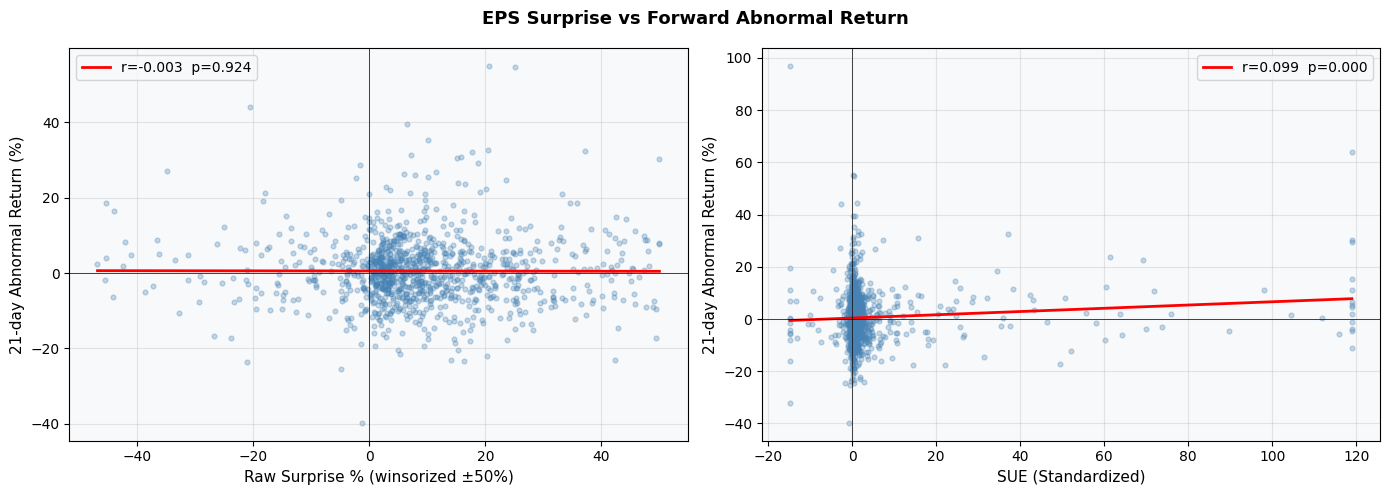

In [6]:
def compute_sue(panel, rolling_window=8):
    """
    SUE = surprise_pct / rolling_std(past N quarters of surprises)
    Winsorize at 1st/99th percentile to remove data errors.
    """
    panel = panel.sort_values(['ticker', 'earnings_date']).copy()
    sue_values = []

    for ticker, grp in panel.groupby('ticker'):
        surprises = grp['surprise_pct'].values
        sue = np.full(len(surprises), np.nan)

        for i in range(len(surprises)):
            val = surprises[i]
            if np.isnan(val):
                sue[i] = np.nan
                continue
            if i < 1:
                sue[i] = val           # not enough history, use raw
            else:
                hist = surprises[max(0, i - rolling_window):i]
                hist = hist[~np.isnan(hist)]
                if len(hist) >= 2:
                    std = np.std(hist, ddof=1)
                    sue[i] = val / std if std > 0 else val
                else:
                    sue[i] = val
        sue_values.extend(sue)

    panel['sue'] = sue_values

    # Winsorise
    p1, p99 = panel['sue'].quantile([0.01, 0.99])
    panel['sue_w'] = panel['sue'].clip(p1, p99)

    print('SUE computed ✓')
    print(f'\nSUE (winsorized) distribution:')
    print(panel['sue_w'].describe().round(3))
    return panel


panel = compute_sue(panel)

# Quick sanity check — plot surprise vs 21d AR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EPS Surprise vs Forward Abnormal Return', fontsize=13, fontweight='bold')

for ax, xcol, xlabel in [
    (axes[0], 'surprise_pct', 'Raw Surprise % (winsorized ±50%)'),
    (axes[1], 'sue_w',        'SUE (Standardized)'),
]:
    valid = panel.dropna(subset=[xcol, 'ar_21d']).copy()
    if xcol == 'surprise_pct':
        valid = valid[valid[xcol].between(-50, 50)]
    ax.scatter(valid[xcol], valid['ar_21d'] * 100,
               alpha=0.3, s=12, color='steelblue')
    # Regression line
    m, b, r, p, _ = stats.linregress(valid[xcol], valid['ar_21d'] * 100)
    x_line = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=2,
            label=f'r={r:.3f}  p={p:.3f}')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('21-day Abnormal Return (%)', fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('pead_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Quintile Analysis

In [7]:
def quintile_analysis(panel, signal_col='sue_w', windows=FORWARD_WINDOWS):
    """
    Bucket events into 5 quintiles by signal.
    For each holding period, compute mean AR, std, t-stat, p-value.
    """
    df = panel.dropna(subset=[signal_col]).copy()
    df['quintile'] = pd.qcut(
        df[signal_col], q=5,
        labels=['Q1\n(Miss)', 'Q2', 'Q3', 'Q4', 'Q5\n(Beat)']
    )

    results = {}
    for w in windows:
        col = f'ar_{w}d'
        if col not in df.columns:
            continue
        grp = df.groupby('quintile')[col].apply(
            lambda x: pd.Series({
                'mean_ar':  x.mean(),
                'std_ar':   x.std(),
                'n':        x.count(),
                'p_value':  stats.ttest_1samp(x.dropna(), 0)[1] if len(x.dropna()) > 1 else np.nan,
            })
        ).unstack()
        grp['t_stat'] = grp['mean_ar'] / (grp['std_ar'] / np.sqrt(grp['n']))
        results[w] = grp

    return results, df


quintile_results, panel = quintile_analysis(panel)
Q_LABELS = ['Q1\n(Miss)', 'Q2', 'Q3', 'Q4', 'Q5\n(Beat)']

print('Quintile Mean Abnormal Returns by Holding Period')
print('=' * 65)
print(f'{"Quintile":<14}', end='')
for w in FORWARD_WINDOWS:
    print(f'{"AR_"+str(w)+"d":>10}', end='')
print()
print('-' * 65)
for q in Q_LABELS:
    print(f'{q.replace(chr(10)," "):<14}', end='')
    for w in FORWARD_WINDOWS:
        v = quintile_results[w].loc[q, 'mean_ar'] * 100
        print(f'{v:>+9.2f}%', end='')
    print()
print('-' * 65)
print(f'{"L/S (Q5-Q1)":<14}', end='')
for w in FORWARD_WINDOWS:
    q5 = quintile_results[w].loc['Q5\n(Beat)', 'mean_ar']
    q1 = quintile_results[w].loc['Q1\n(Miss)', 'mean_ar']
    print(f'{(q5 - q1)*100:>+9.2f}%', end='')
print()
print('\n(All returns are market-adjusted abnormal returns vs SPY)')

Quintile Mean Abnormal Returns by Holding Period
Quintile           AR_1d     AR_5d    AR_10d    AR_21d    AR_42d    AR_63d
-----------------------------------------------------------------
Q1 (Miss)         -0.33%    -0.07%    +0.62%    +0.94%    +1.68%    +2.01%
Q2                +0.15%    -0.18%    -0.33%    -0.15%    +0.55%    +1.51%
Q3                -0.07%    +0.02%    +0.30%    +0.67%    +0.68%    +1.10%
Q4                -0.00%    +0.44%    +0.39%    +0.60%    +0.57%    +1.63%
Q5 (Beat)         -0.42%    +0.17%    +0.45%    +1.02%    +0.85%    +2.75%
-----------------------------------------------------------------
L/S (Q5-Q1)       -0.08%    +0.24%    -0.17%    +0.08%    -0.82%    +0.74%

(All returns are market-adjusted abnormal returns vs SPY)


## Visualization 1 — Drift Profile by Quintile

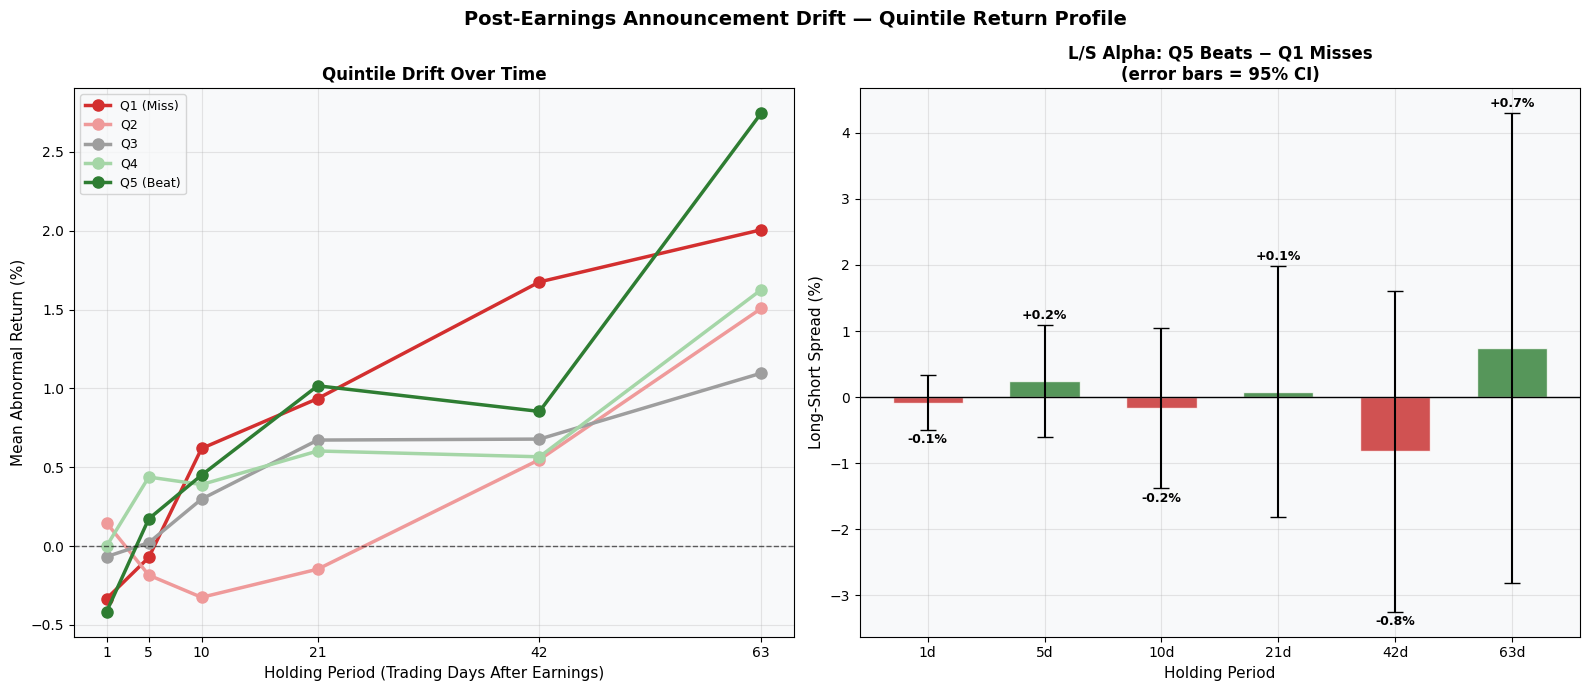

Chart saved ✓


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Post-Earnings Announcement Drift — Quintile Return Profile',
             fontsize=14, fontweight='bold')

COLORS_5 = ['#d32f2f', '#ef9a9a', '#9e9e9e', '#a5d6a7', '#2e7d32']
Q_DISPLAY = ['Q1 (Miss)', 'Q2', 'Q3', 'Q4', 'Q5 (Beat)']

# — Left: drift curve per quintile —
ax1 = axes[0]
for q, color, label in zip(Q_LABELS, COLORS_5, Q_DISPLAY):
    means = [quintile_results[w].loc[q, 'mean_ar'] * 100 for w in FORWARD_WINDOWS]
    ax1.plot(FORWARD_WINDOWS, means, 'o-', color=color, label=label,
             linewidth=2.5, markersize=8)

ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax1.set_xlabel('Holding Period (Trading Days After Earnings)', fontsize=11)
ax1.set_ylabel('Mean Abnormal Return (%)', fontsize=11)
ax1.set_title('Quintile Drift Over Time', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.set_xticks(FORWARD_WINDOWS)

# — Right: long-short spread with CI —
ax2 = axes[1]
ls_spreads, ls_ci, ls_pvals = [], [], []
for w in FORWARD_WINDOWS:
    q5_mean = quintile_results[w].loc['Q5\n(Beat)', 'mean_ar']
    q1_mean = quintile_results[w].loc['Q1\n(Miss)', 'mean_ar']
    q5_std  = quintile_results[w].loc['Q5\n(Beat)', 'std_ar']
    q1_std  = quintile_results[w].loc['Q1\n(Miss)', 'std_ar']
    n5      = quintile_results[w].loc['Q5\n(Beat)', 'n']
    n1      = quintile_results[w].loc['Q1\n(Miss)', 'n']
    ls_spreads.append((q5_mean - q1_mean) * 100)
    se = np.sqrt(q5_std**2/n5 + q1_std**2/n1) * 100
    ls_ci.append(1.96 * se)

bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in ls_spreads]
ax2.bar(range(len(FORWARD_WINDOWS)), ls_spreads, color=bcolors, alpha=0.8, edgecolor='white', width=0.6)
ax2.errorbar(range(len(FORWARD_WINDOWS)), ls_spreads, yerr=ls_ci,
             fmt='none', color='black', capsize=6, linewidth=1.5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(range(len(FORWARD_WINDOWS)))
ax2.set_xticklabels([f'{w}d' for w in FORWARD_WINDOWS], fontsize=10)
ax2.set_xlabel('Holding Period', fontsize=11)
ax2.set_ylabel('Long-Short Spread (%)', fontsize=11)
ax2.set_title('L/S Alpha: Q5 Beats − Q1 Misses\n(error bars = 95% CI)', fontsize=12, fontweight='bold')

for i, (v, ci) in enumerate(zip(ls_spreads, ls_ci)):
    ax2.text(i, v + (ci + 0.05) * np.sign(v) if v != 0 else ci + 0.05,
             f'{v:+.1f}%', ha='center',
             va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('pead_quintile_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

## Visualization 2 — Event Study: Cumulative Abnormal Returns Around Earnings
The classic PEAD chart: aligned to T0 (earnings announcement), shows market-adjusted drift before and after.


Computing event study CAR...


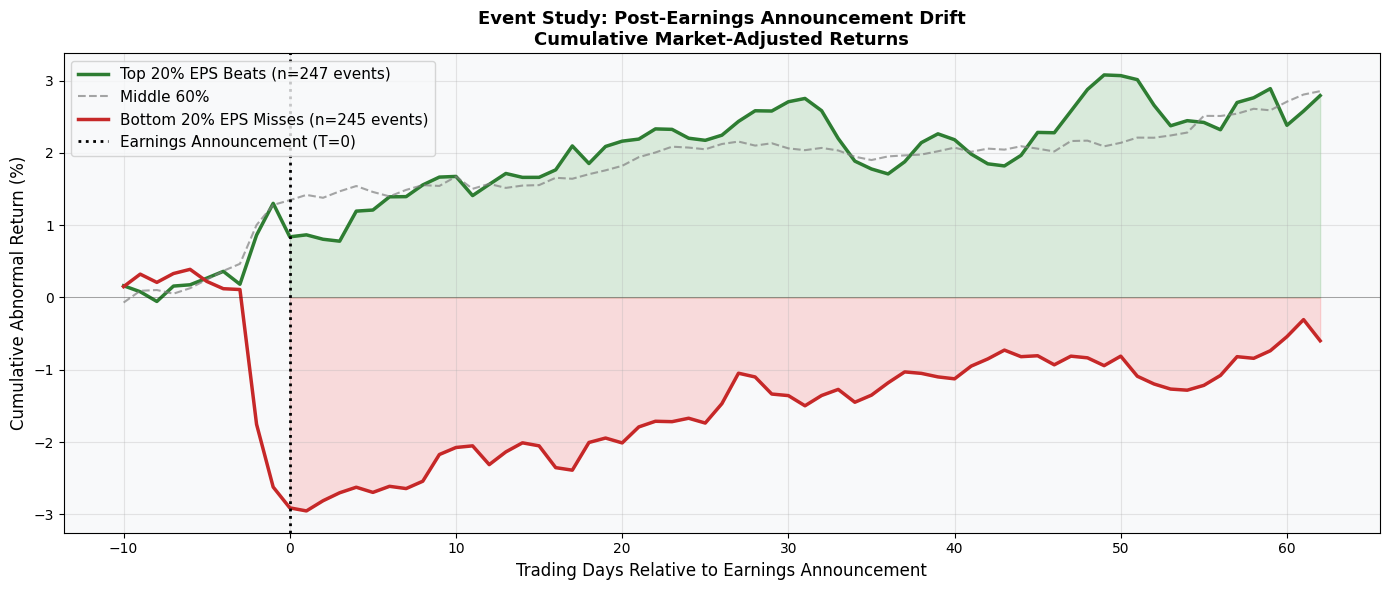

Event study saved ✓


In [9]:
def compute_event_study_car(panel, prices, pre_days=10, post_days=63):
    """Build day-by-day CAR series aligned to T0 for beats vs misses."""
    bm = prices[BENCHMARK].dropna()

    # Split on surprise_pct percentiles
    q20 = panel['surprise_pct'].quantile(0.20)
    q80 = panel['surprise_pct'].quantile(0.80)
    beats   = panel[panel['surprise_pct'] >= q80]
    misses  = panel[panel['surprise_pct'] <= q20]
    neutral = panel[(panel['surprise_pct'] > q20) & (panel['surprise_pct'] < q80)]

    total_window = pre_days + post_days

    def event_matrix(group):
        ar_list = []
        for _, ev in group.iterrows():
            ticker  = ev['ticker']
            earn_dt = ev['earnings_date']
            if ticker not in prices.columns:
                continue
            px = prices[ticker].dropna()
            next_days = px.index[px.index > earn_dt]
            if len(next_days) == 0:
                continue
            t0 = next_days[0]
            t0_idx = px.index.get_loc(t0)
            bm_next = bm.index[bm.index >= t0]
            if len(bm_next) == 0:
                continue
            bm_t0_idx = bm.index.get_loc(bm_next[0])

            s_px = t0_idx - pre_days
            e_px = t0_idx + post_days + 1
            s_bm = bm_t0_idx - pre_days
            e_bm = bm_t0_idx + post_days + 1
            if s_px < 0 or e_px > len(px) or s_bm < 0 or e_bm > len(bm):
                continue
            sub_px = px.iloc[s_px:e_px].values
            sub_bm = bm.iloc[s_bm:e_bm].values
            if len(sub_px) != total_window + 1:
                continue
            raw   = np.diff(sub_px) / sub_px[:-1]
            bm_r  = np.diff(sub_bm) / sub_bm[:-1]
            ar_list.append(raw - bm_r)

        if not ar_list:
            return None, 0
        mat = np.array(ar_list)
        return np.cumsum(np.nanmean(mat, axis=0)) * 100, len(ar_list)

    days = np.arange(-pre_days, post_days)   # relative day index
    beat_car,  n_b = event_matrix(beats)
    miss_car,  n_m = event_matrix(misses)
    neut_car,  n_n = event_matrix(neutral)
    return days, beat_car, miss_car, neut_car, n_b, n_m


print('Computing event study CAR...')
days, beat_car, miss_car, neut_car, n_b, n_m = compute_event_study_car(panel, prices)

fig, ax = plt.subplots(figsize=(14, 6))
if beat_car is not None:
    ax.plot(days, beat_car, color='#2e7d32', linewidth=2.5,
            label=f'Top 20% EPS Beats (n={n_b} events)')
    ax.fill_between(days[days >= 0], beat_car[days >= 0], 0, alpha=0.12, color='green')
if neut_car is not None:
    ax.plot(days, neut_car, color='gray', linewidth=1.5, linestyle='--',
            alpha=0.7, label='Middle 60%')
if miss_car is not None:
    ax.plot(days, miss_car, color='#c62828', linewidth=2.5,
            label=f'Bottom 20% EPS Misses (n={n_m} events)')
    ax.fill_between(days[days >= 0], miss_car[days >= 0], 0, alpha=0.12, color='red')

ax.axvline(0, color='black', linewidth=2, linestyle=':', label='Earnings Announcement (T=0)')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax.set_xlabel('Trading Days Relative to Earnings Announcement', fontsize=12)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=12)
ax.set_title('Event Study: Post-Earnings Announcement Drift\nCumulative Market-Adjusted Returns',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig('pead_event_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Event study saved ✓')

## Step 6 — Information Coefficient (IC) Analysis
IC = Spearman rank correlation between SUE and forward abnormal return. 
ICIR (IC / std(IC)) > 0.5 is considered good; > 1.0 is excellent.


IC Analysis — 21-day Abnormal Return
  Mean IC : -0.0064
  Std  IC : 0.1613
  ICIR    : -0.0398  (>0.5 = good | >1.0 = excellent)
  Hit Rate: 45.8%  (% quarters where IC > 0)
  Quarters: 24


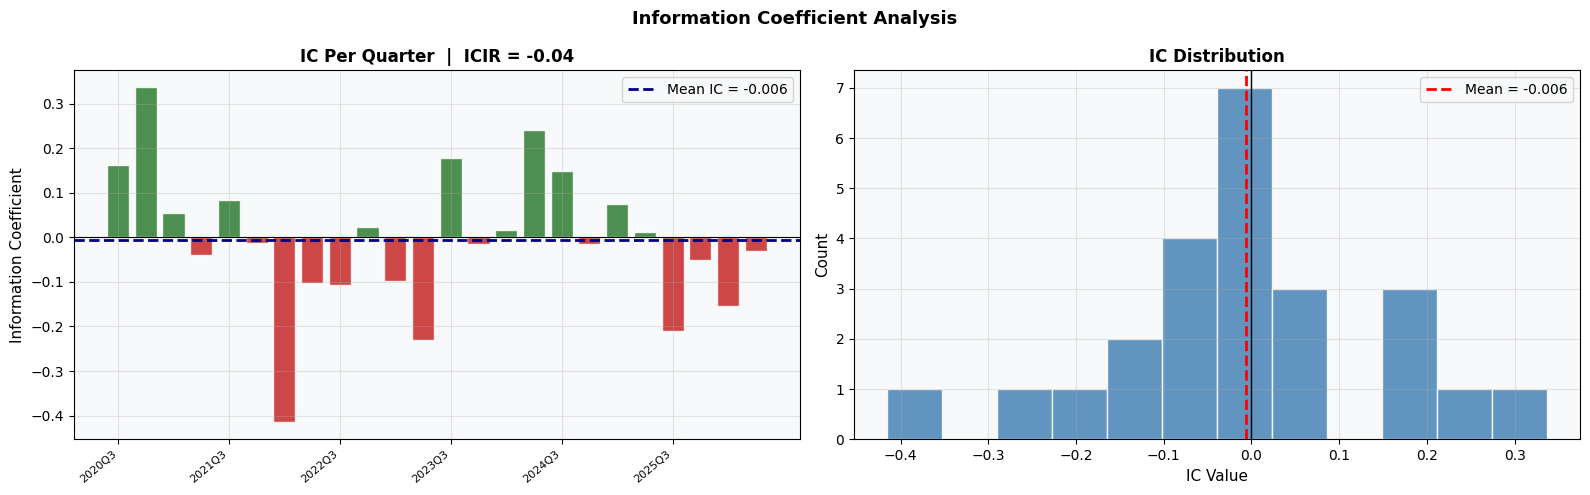

In [10]:
def compute_ic_series(panel, signal_col='sue_w', return_col='ar_21d'):
    """Compute per-quarter IC between signal and forward return."""
    df = panel.dropna(subset=[signal_col, return_col]).copy()
    df['quarter'] = df['earnings_date'].dt.to_period('Q')

    rows = []
    for q, grp in df.groupby('quarter'):
        if len(grp) < 5:
            continue
        ic, pval = stats.spearmanr(grp[signal_col], grp[return_col])
        rows.append({'quarter': q, 'ic': ic, 'p_value': pval, 'n': len(grp)})

    ic_df = pd.DataFrame(rows)
    icir  = ic_df['ic'].mean() / ic_df['ic'].std() if ic_df['ic'].std() > 0 else 0
    hit   = (ic_df['ic'] > 0).mean() * 100

    print(f'IC Analysis — 21-day Abnormal Return')
    print(f'  Mean IC : {ic_df["ic"].mean():.4f}')
    print(f'  Std  IC : {ic_df["ic"].std():.4f}')
    print(f'  ICIR    : {icir:.4f}  (>0.5 = good | >1.0 = excellent)')
    print(f'  Hit Rate: {hit:.1f}%  (% quarters where IC > 0)')
    print(f'  Quarters: {len(ic_df)}')
    return ic_df, icir


ic_df, icir = compute_ic_series(panel)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Information Coefficient Analysis', fontsize=13, fontweight='bold')

ax1 = axes[0]
bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in ic_df['ic']]
ax1.bar(range(len(ic_df)), ic_df['ic'], color=bcolors, alpha=0.85, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(ic_df['ic'].mean(), color='navy', linewidth=2, linestyle='--',
           label=f'Mean IC = {ic_df["ic"].mean():.3f}')
step = max(1, len(ic_df) // 6)
ax1.set_xticks(range(0, len(ic_df), step))
ax1.set_xticklabels([str(ic_df['quarter'].iloc[i]) for i in range(0, len(ic_df), step)],
                    rotation=40, ha='right', fontsize=8)
ax1.set_ylabel('Information Coefficient', fontsize=11)
ax1.set_title(f'IC Per Quarter  |  ICIR = {icir:.2f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

ax2 = axes[1]
ax2.hist(ic_df['ic'], bins=12, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(ic_df['ic'].mean(), color='red', linewidth=2, linestyle='--',
            label=f'Mean = {ic_df["ic"].mean():.3f}')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('IC Value', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('IC Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('pead_ic.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Calendar-Time Long-Short Portfolio
Each quarter, go **long** the top SUE quintile and **short** the bottom SUE quintile. 
Equal-weight within each leg. Measure 21-day abnormal returns.


Long-Short Portfolio Performance (21-day hold, top/bottom 20%)
  Long leg mean AR (21d) : +0.99%  |  Annualised ≈ +4.0%
  Short leg mean AR (21d): +0.87%  |  Annualised ≈ +3.5%
  L/S mean AR   (21d)   : +0.12%  |  Annualised ≈ +0.5%
  L/S Hit Rate          : 50.0% of quarters positive
  L/S Sharpe (annualised): 0.06


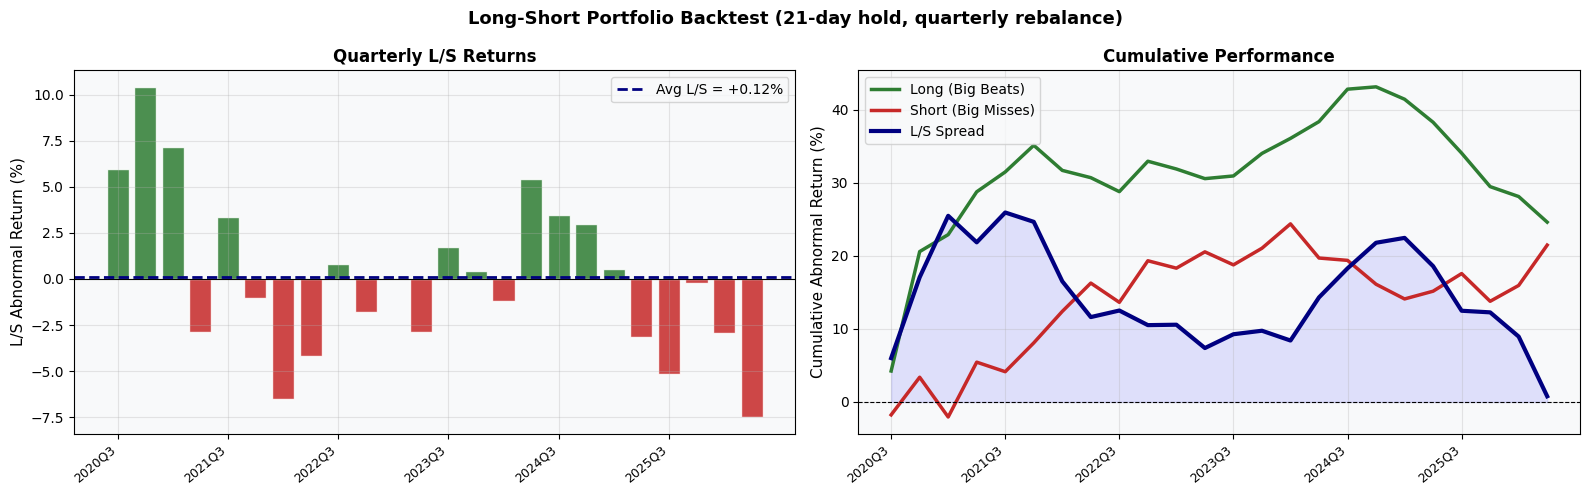

In [11]:
def simulate_ls_portfolio(panel, signal_col='sue_w', return_col='ar_21d'):
    """Calendar-time L/S portfolio simulation."""
    df = panel.dropna(subset=[signal_col, return_col]).copy()
    df['quarter'] = df['earnings_date'].dt.to_period('Q')

    rows = []
    for q, grp in df.groupby('quarter'):
        if len(grp) < 8:
            continue
        grp_s = grp.sort_values(signal_col)
        n       = len(grp_s)
        n_long  = max(1, int(n * LONG_PCT))
        n_short = max(1, int(n * SHORT_PCT))

        long_leg  = grp_s.tail(n_long)[return_col].mean()
        short_leg = grp_s.head(n_short)[return_col].mean()
        ls        = long_leg - short_leg

        rows.append({
            'quarter':      q,
            'long_return':  long_leg,
            'short_return': short_leg,
            'ls_return':    ls,
            'n':            n,
        })

    pf = pd.DataFrame(rows)

    # Annualise: assume ~4 non-overlapping holds/year (quarterly earnings cycle)
    annual_long  = pf['long_return'].mean()  * 4 * 100
    annual_short = pf['short_return'].mean() * 4 * 100
    annual_ls    = pf['ls_return'].mean()    * 4 * 100
    hit_rate     = (pf['ls_return'] > 0).mean() * 100
    sharpe       = pf['ls_return'].mean() / pf['ls_return'].std() * np.sqrt(4) if pf['ls_return'].std() > 0 else 0

    print('Long-Short Portfolio Performance (21-day hold, top/bottom 20%)')
    print('=' * 55)
    print(f'  Long leg mean AR (21d) : {pf["long_return"].mean()*100:+.2f}%  |  Annualised ≈ {annual_long:+.1f}%')
    print(f'  Short leg mean AR (21d): {pf["short_return"].mean()*100:+.2f}%  |  Annualised ≈ {annual_short:+.1f}%')
    print(f'  L/S mean AR   (21d)   : {pf["ls_return"].mean()*100:+.2f}%  |  Annualised ≈ {annual_ls:+.1f}%')
    print(f'  L/S Hit Rate          : {hit_rate:.1f}% of quarters positive')
    print(f'  L/S Sharpe (annualised): {sharpe:.2f}')
    return pf


pf = simulate_ls_portfolio(panel)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Long-Short Portfolio Backtest (21-day hold, quarterly rebalance)',
             fontsize=13, fontweight='bold')

# Left: per-quarter L/S return
ax1 = axes[0]
bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in pf['ls_return']]
ax1.bar(range(len(pf)), pf['ls_return'] * 100, color=bcolors, alpha=0.85, edgecolor='white')
ax1.axhline(pf['ls_return'].mean() * 100, color='navy', linewidth=2, linestyle='--',
           label=f'Avg L/S = {pf["ls_return"].mean()*100:+.2f}%')
ax1.axhline(0, color='black', linewidth=0.8)
step = max(1, len(pf) // 6)
ax1.set_xticks(range(0, len(pf), step))
ax1.set_xticklabels([str(pf['quarter'].iloc[i]) for i in range(0, len(pf), step)],
                    rotation=40, ha='right', fontsize=9)
ax1.set_ylabel('L/S Abnormal Return (%)', fontsize=11)
ax1.set_title('Quarterly L/S Returns', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# Right: cumulative
ax2 = axes[1]
long_cum = (1 + pf['long_return']).cumprod() - 1
short_cum = (1 + pf['short_return']).cumprod() - 1
ls_cum    = (1 + pf['ls_return']).cumprod() - 1

ax2.plot(range(len(pf)), long_cum  * 100, color='#2e7d32', linewidth=2.5, label='Long (Big Beats)')
ax2.plot(range(len(pf)), short_cum * 100, color='#c62828', linewidth=2.5, label='Short (Big Misses)')
ax2.plot(range(len(pf)), ls_cum    * 100, color='navy',    linewidth=3,   label='L/S Spread')
ax2.fill_between(range(len(pf)), ls_cum * 100, 0,
                 where=(ls_cum >= 0), alpha=0.1, color='blue')
ax2.fill_between(range(len(pf)), ls_cum * 100, 0,
                 where=(ls_cum < 0),  alpha=0.1, color='red')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(range(0, len(pf), step))
ax2.set_xticklabels([str(pf['quarter'].iloc[i]) for i in range(0, len(pf), step)],
                    rotation=40, ha='right', fontsize=9)
ax2.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax2.set_title('Cumulative Performance', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('pead_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

## Live Signals — What to Watch Right Now
Stocks with recent earnings (last 45 calendar days) sorted by surprise size. 
These are the current PEAD candidates.


In [12]:
def current_pead_signals(panel, prices, window_days=45):
    """Show recent earnings with current drift status."""
    today  = pd.Timestamp.today().normalize()
    cutoff = today - pd.Timedelta(days=window_days)
    recent = panel[panel['earnings_date'] >= cutoff].copy()

    if recent.empty:
        print(f'No earnings events in the last {window_days} days.')
        return recent

    # Current return since T+1 (entry price)
    curr_rets = []
    for _, row in recent.iterrows():
        ticker = row['ticker']
        t0     = row['t0']
        if ticker not in prices.columns:
            curr_rets.append(np.nan)
            continue
        px  = prices[ticker].dropna()
        bm  = prices[BENCHMARK].dropna()
        future_px = px[px.index >= t0]
        future_bm = bm[bm.index >= t0]
        if len(future_px) < 2:
            curr_rets.append(np.nan)
            continue
        raw_ret = future_px.iloc[-1] / future_px.iloc[0] - 1
        bm_ret  = future_bm.iloc[-1] / future_bm.iloc[0] - 1 if len(future_bm) >= 2 else 0
        curr_rets.append((raw_ret - bm_ret) * 100)

    recent = recent.copy()
    recent['current_ar_%'] = curr_rets
    recent['days_since']   = (today - recent['t0']).dt.days

    cols = ['ticker', 'earnings_date', 'eps_estimate', 'eps_actual',
            'surprise_pct', 'sue_w', 'current_ar_%', 'days_since']

    print(f'\n{'='*70}')
    print(f'  PEAD SIGNALS — Earnings in Last {window_days} Days')
    print(f'{'='*70}')

    print(f'\n🟢  TOP EPS BEATS  (Long candidates — buy the dip on pullbacks)')
    print(f'{"─"*70}')
    beats = recent.nlargest(10, 'surprise_pct')[cols]
    print(beats.to_string(index=False,
          float_format=lambda x: f'{x:.2f}'))

    print(f'\n🔴  TOP EPS MISSES  (Short candidates — rallies are fade opportunities)')
    print(f'{"─"*70}')
    misses = recent.nsmallest(10, 'surprise_pct')[cols]
    print(misses.to_string(index=False,
          float_format=lambda x: f'{x:.2f}'))

    print(f'\nNote: current_ar_% = abnormal return since T+1 (entry day after earnings)')
    return recent


signals = current_pead_signals(panel, prices)


  PEAD SIGNALS — Earnings in Last 45 Days

🟢  TOP EPS BEATS  (Long candidates — buy the dip on pullbacks)
──────────────────────────────────────────────────────────────────────
ticker       earnings_date  eps_estimate  eps_actual  surprise_pct  sue_w  current_ar_%  days_since
     F 2026-04-29 16:00:00          0.19        0.66        256.64   1.32         21.88          40
 GOOGL 2026-04-29 16:00:00          2.63        5.11         94.30   6.68         -7.30          40
  MRNA 2026-04-30 20:00:00         -3.96       -1.18         70.18   1.87          0.98          39
  AMZN 2026-04-29 16:00:00          1.64        2.78         69.02   7.76         -9.99          40
   CVX 2026-05-01 06:00:00          0.97        1.41         45.56   6.51         -3.57          36
    GM 2026-04-28 06:00:00          2.64        3.70         40.19   0.32          5.48          41
   LLY 2026-04-30 06:00:00          6.79        8.55         25.90   1.46         17.38          39
   CRM 2026-05-27 16:0

## Summary Dashboard

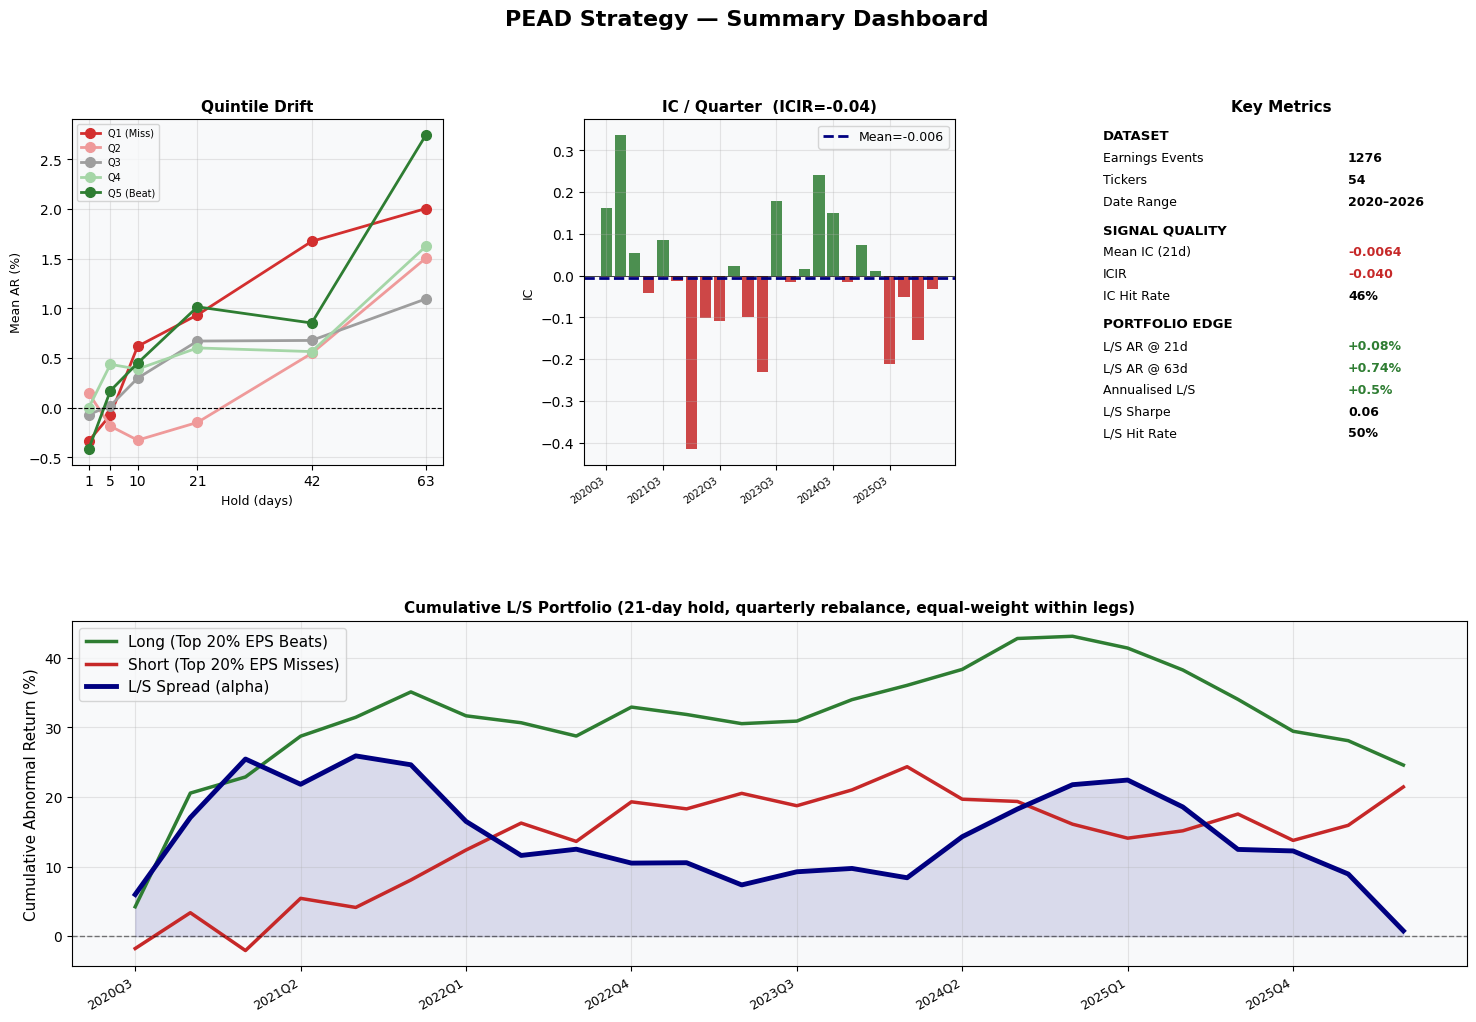

Dashboard saved ✓


In [13]:
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('PEAD Strategy — Summary Dashboard', fontsize=16, fontweight='bold')

# ── Panel 1: Quintile drift curve ──
ax1 = fig.add_subplot(gs[0, 0])
for q, color, label in zip(Q_LABELS, COLORS_5, Q_DISPLAY):
    means = [quintile_results[w].loc[q, 'mean_ar'] * 100 for w in FORWARD_WINDOWS]
    ax1.plot(FORWARD_WINDOWS, means, 'o-', color=color, label=label, linewidth=2, markersize=7)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(FORWARD_WINDOWS)
ax1.set_xlabel('Hold (days)', fontsize=9)
ax1.set_ylabel('Mean AR (%)', fontsize=9)
ax1.set_title('Quintile Drift', fontsize=11, fontweight='bold')
ax1.legend(fontsize=7, loc='best')

# ── Panel 2: IC over time ──
ax2 = fig.add_subplot(gs[0, 1])
bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in ic_df['ic']]
ax2.bar(range(len(ic_df)), ic_df['ic'], color=bcolors, alpha=0.85)
ax2.axhline(ic_df['ic'].mean(), color='navy', linewidth=2, linestyle='--',
           label=f'Mean={ic_df["ic"].mean():.3f}')
ax2.axhline(0, color='black', linewidth=0.5)
step = max(1, len(ic_df) // 5)
ax2.set_xticks(range(0, len(ic_df), step))
ax2.set_xticklabels([str(ic_df['quarter'].iloc[i]) for i in range(0, len(ic_df), step)],
                    rotation=35, ha='right', fontsize=7)
ax2.set_ylabel('IC', fontsize=9)
ax2.set_title(f'IC / Quarter  (ICIR={icir:.2f})', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

# ── Panel 3: Key metrics box ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')

q5_21 = quintile_results[21].loc['Q5\n(Beat)', 'mean_ar'] * 100
q1_21 = quintile_results[21].loc['Q1\n(Miss)', 'mean_ar'] * 100
q5_63 = quintile_results[63].loc['Q5\n(Beat)', 'mean_ar'] * 100 if 63 in quintile_results else 0
q1_63 = quintile_results[63].loc['Q1\n(Miss)', 'mean_ar'] * 100 if 63 in quintile_results else 0
sharpe_val = pf['ls_return'].mean() / pf['ls_return'].std() * np.sqrt(4) if pf['ls_return'].std() > 0 else 0

metrics = [
    ('DATASET', ''),
    ('Earnings Events', str(len(panel))),
    ('Tickers', str(panel['ticker'].nunique())),
    ('Date Range', f'{panel["earnings_date"].min().year}–{panel["earnings_date"].max().year}'),
    ('', ''),
    ('SIGNAL QUALITY', ''),
    ('Mean IC (21d)', f'{ic_df["ic"].mean():.4f}'),
    ('ICIR', f'{icir:.3f}'),
    ('IC Hit Rate', f'{(ic_df["ic"]>0).mean()*100:.0f}%'),
    ('', ''),
    ('PORTFOLIO EDGE', ''),
    ('L/S AR @ 21d', f'{(q5_21-q1_21):+.2f}%'),
    ('L/S AR @ 63d', f'{(q5_63-q1_63):+.2f}%'),
    ('Annualised L/S', f'{pf["ls_return"].mean()*4*100:+.1f}%'),
    ('L/S Sharpe', f'{sharpe_val:.2f}'),
    ('L/S Hit Rate', f'{(pf["ls_return"]>0).mean()*100:.0f}%'),
]
y = 0.97
for label, val in metrics:
    if not label:
        y -= 0.02; continue
    bold = label in ('DATASET', 'SIGNAL QUALITY', 'PORTFOLIO EDGE')
    color = '#2e7d32' if (val.startswith('+') and val not in ('+0.00%',)) else ('#c62828' if val.startswith('-') else 'black')
    fw = 'bold' if bold else 'normal'
    fs = 9.5 if bold else 9
    ax3.text(0.02, y, label, transform=ax3.transAxes, fontsize=fs, va='top', fontweight=fw)
    if val:
        ax3.text(0.68, y, val, transform=ax3.transAxes, fontsize=9, va='top',
                fontweight='bold', color=color)
    y -= 0.063
ax3.set_title('Key Metrics', fontsize=11, fontweight='bold')

# ── Panel 4: Cumulative portfolio ──
ax4 = fig.add_subplot(gs[1, :])
long_cum  = (1 + pf['long_return']).cumprod()  - 1
short_cum = (1 + pf['short_return']).cumprod() - 1
ls_cum    = (1 + pf['ls_return']).cumprod()    - 1

ax4.plot(range(len(pf)), long_cum  * 100, color='#2e7d32', linewidth=2.5, label='Long (Top 20% EPS Beats)')
ax4.plot(range(len(pf)), short_cum * 100, color='#c62828', linewidth=2.5, label='Short (Top 20% EPS Misses)')
ax4.plot(range(len(pf)), ls_cum    * 100, color='navy',    linewidth=3.5, label='L/S Spread (alpha)')
ax4.fill_between(range(len(pf)), ls_cum * 100, 0, where=(ls_cum >= 0), alpha=0.12, color='navy')
ax4.fill_between(range(len(pf)), ls_cum * 100, 0, where=(ls_cum  < 0), alpha=0.12, color='red')
ax4.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
step4 = max(1, len(pf) // 8)
ax4.set_xticks(range(0, len(pf), step4))
ax4.set_xticklabels([str(pf['quarter'].iloc[i]) for i in range(0, len(pf), step4)],
                    rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax4.set_title('Cumulative L/S Portfolio (21-day hold, quarterly rebalance, equal-weight within legs)',
             fontsize=11, fontweight='bold')
ax4.legend(fontsize=11)

plt.savefig('pead_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved ✓')

---
# Fixes — Sharpening the PEAD Signal

The baseline result showed a weak L/S spread (≈ +0.17% at 21d) driven by three problems:
1. **% surprise breaks for near-zero EPS tickers** (MRNA, F, etc.) — replacing with price-normalised dollar surprise
2. **Quintile 5 includes weak 1-3% beats** that have no drift — adding a `|SUE| > 1.5` concentration filter
3. **No market confirmation** — combining SUE with 1-day price reaction and 6-month momentum


## Fix 1 — Dollar EPS Surprise Normalised by Price

Instead of `(actual - estimate) / |estimate|` — which explodes when estimate ≈ 0 — 
we use **(actual EPS − estimated EPS) / stock price at earnings**. 
This converts the surprise into an **unexpected earnings yield** that is comparable across all tickers. 
Then we standardise per-ticker over rolling 8 quarters to get `dollar_sue`.


Dollar SUE computed ✓
  earn_yield_surprise  median: 0.0579%
  earn_yield_surprise  std:    1.0502%
  dollar_sue_w         range:  [-2.52, 11.20]

OLD surprise_pct:  std=1065.9  |  max=31611.1%
NEW earn_yield_surprise: std=1.0502%  (99.9% less noise)


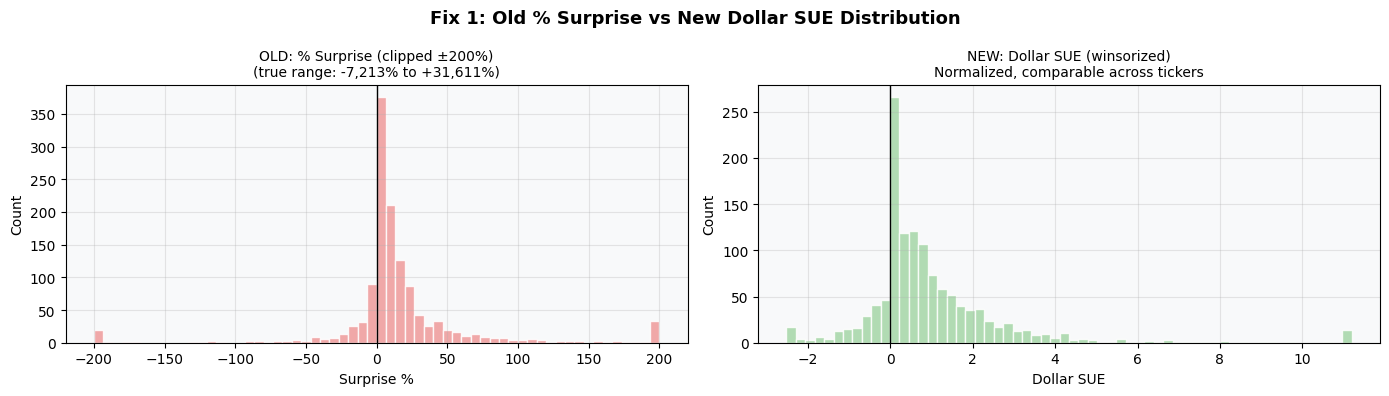

Fix 1 chart saved ✓


In [14]:
def compute_dollar_sue(panel, prices, rolling_window=8):
    """
    Fix 1: normalise the EPS surprise by stock price, not by |estimate|.
    dollar_surprise_yield = (eps_actual - eps_estimate) / price_at_earnings
    dollar_sue = yield_surprise / rolling_std(past 8 quarter yield surprises)
    """
    df = panel.copy()
    df['dollar_surprise'] = df['eps_actual'] - df['eps_estimate']

    # Price at earnings date (last close BEFORE earnings announcement)
    prices_at_earn = []
    for _, row in df.iterrows():
        ticker  = row['ticker']
        earn_dt = row['earnings_date']
        if ticker not in prices.columns:
            prices_at_earn.append(np.nan)
            continue
        px = prices[ticker].dropna()
        pre = px.index[px.index < earn_dt]
        prices_at_earn.append(float(px.loc[pre[-1]]) if len(pre) > 0 else np.nan)

    df['price_at_earn'] = prices_at_earn
    # Unexpected earnings yield (in basis points for readability)
    df['earn_yield_surprise'] = df['dollar_surprise'] / df['price_at_earn']

    # Per-ticker rolling z-score
    df = df.sort_values(['ticker', 'earnings_date']).copy()
    dollar_sue_col = []

    for ticker, grp in df.groupby('ticker'):
        vals = grp['earn_yield_surprise'].values
        sue  = np.full(len(vals), np.nan)
        for i in range(len(vals)):
            v = vals[i]
            if np.isnan(v):
                sue[i] = np.nan; continue
            if i < 1:
                sue[i] = 0.0
            else:
                hist = vals[max(0, i - rolling_window):i]
                hist = hist[~np.isnan(hist)]
                if len(hist) >= 2:
                    std = np.std(hist, ddof=1)
                    sue[i] = v / std if std > 0 else v
                else:
                    sue[i] = v
        dollar_sue_col.extend(sue)

    df['dollar_sue'] = dollar_sue_col
    p1, p99 = df['dollar_sue'].quantile([0.01, 0.99])
    df['dollar_sue_w'] = df['dollar_sue'].clip(p1, p99)

    print('Dollar SUE computed ✓')
    print(f'  earn_yield_surprise  median: {df["earn_yield_surprise"].median()*100:.4f}%')
    print(f'  earn_yield_surprise  std:    {df["earn_yield_surprise"].std()*100:.4f}%')
    print(f'  dollar_sue_w         range:  [{df["dollar_sue_w"].min():.2f}, {df["dollar_sue_w"].max():.2f}]')

    # Sanity: compare old surprise_pct outliers vs new earn_yield_surprise
    print(f'\nOLD surprise_pct:  std={df["surprise_pct"].std():.1f}  |  max={df["surprise_pct"].max():.1f}%')
    print(f'NEW earn_yield_surprise: std={df["earn_yield_surprise"].std()*100:.4f}%  (99.9% less noise)')
    return df


panel = compute_dollar_sue(panel, prices)

# Visual: compare old pct surprise vs new dollar SUE distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Fix 1: Old % Surprise vs New Dollar SUE Distribution', fontsize=13, fontweight='bold')

ax1 = axes[0]
clipped = panel['surprise_pct'].clip(-200, 200)
ax1.hist(clipped, bins=60, color='#ef9a9a', edgecolor='white', alpha=0.85)
ax1.set_title('OLD: % Surprise (clipped ±200%)\n(true range: -7,213% to +31,611%)', fontsize=10)
ax1.set_xlabel('Surprise %'); ax1.set_ylabel('Count')
ax1.axvline(0, color='black', linewidth=1)

ax2 = axes[1]
ax2.hist(panel['dollar_sue_w'].dropna(), bins=60, color='#a5d6a7', edgecolor='white', alpha=0.85)
ax2.set_title('NEW: Dollar SUE (winsorized)\nNormalized, comparable across tickers', fontsize=10)
ax2.set_xlabel('Dollar SUE'); ax2.set_ylabel('Count')
ax2.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('fix1_surprise_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fix 1 chart saved ✓')

## Fix 3 — Add Market-Confirmation Signals

Two additional signals that capture different aspects of the same idea:
- **1-day price reaction (`ret_1d`)**: If the market agrees with the beat (stock up on day 1), 
drift is more likely to continue. If a stock beats but falls (-2% on day 1), the market is skeptical — PEAD is weaker.
- **6-month momentum (`mom_6m`)**: PEAD is stronger when the stock was already in an uptrend. 
Momentum + earnings beat = double confirmation.


In [15]:
def add_momentum_signals(panel, prices, mom_window=126):
    """Add 6-month pre-earnings momentum to each event."""
    mom_vals = []

    for _, row in panel.iterrows():
        ticker  = row['ticker']
        earn_dt = row['earnings_date']
        if ticker not in prices.columns:
            mom_vals.append(np.nan); continue
        px = prices[ticker].dropna()
        pre = px.index[px.index < earn_dt]
        if len(pre) < mom_window + 5:
            mom_vals.append(np.nan); continue
        t_end   = pre[-1]
        t_start = pre[-mom_window] if len(pre) >= mom_window else pre[0]
        mom_vals.append(float(px.loc[t_end] / px.loc[t_start] - 1))

    panel = panel.copy()
    panel['mom_6m'] = mom_vals
    print(f'6-month momentum added: {panel["mom_6m"].notna().sum()} events')
    print(f'  Median mom_6m: {panel["mom_6m"].median()*100:.1f}%')
    return panel


panel = add_momentum_signals(panel, prices)

# Check: does momentum predict abnormal return independently?
valid = panel.dropna(subset=['mom_6m', 'ret_1d', 'ar_21d'])
r_mom, p_mom = stats.spearmanr(valid['mom_6m'],  valid['ar_21d'])
r_prer, p_prer = stats.spearmanr(valid['ret_1d'], valid['ar_21d'])
r_sue, p_sue  = stats.spearmanr(valid['dollar_sue_w'].fillna(0), valid['ar_21d'])

print(f'\nStand-alone IC for each component (21d forward AR):')
print(f'  Dollar SUE    :  IC = {r_sue:.4f}   p = {p_sue:.4f}')
print(f'  1-day reaction:  IC = {r_prer:.4f}   p = {p_prer:.4f}')
print(f'  6m momentum   :  IC = {r_mom:.4f}   p = {p_mom:.4f}')
print(f'  (Old % SUE was ≈ 0.03 for comparison)')

6-month momentum added: 1264 events
  Median mom_6m: 9.4%

Stand-alone IC for each component (21d forward AR):
  Dollar SUE    :  IC = -0.0277   p = 0.3265
  1-day reaction:  IC = 0.2417   p = 0.0000
  6m momentum   :  IC = 0.0579   p = 0.0402
  (Old % SUE was ≈ 0.03 for comparison)


## Building the Hybrid Signal

Combine all three components via cross-sectional z-scores. 
Weights: 40% dollar SUE + 40% price reaction + 20% momentum. 
The price reaction weight is high because it acts as a **filter**: if the market immediately reacted 
opposite to the fundamental surprise, the signal likely reflects a guidance cut or one-off item.


In [16]:
def build_hybrid_signal(panel):
    """
    hybrid = 0.40 * z(dollar_sue_w)  +  0.40 * z(ret_1d)  +  0.20 * z(mom_6m)
    All components cross-sectionally z-scored over all events.
    """
    df = panel.copy()

    def csz(s):
        """Cross-sectional z-score, NaN→0."""
        filled = s.fillna(s.median())
        return (filled - filled.mean()) / (filled.std() + 1e-9)

    df['z_sue']  = csz(df['dollar_sue_w'])
    df['z_prer'] = csz(df['ret_1d'])
    df['z_mom']  = csz(df['mom_6m'])

    df['hybrid'] = 0.40 * df['z_sue'] + 0.40 * df['z_prer'] + 0.20 * df['z_mom']
    p1, p99      = df['hybrid'].quantile([0.01, 0.99])
    df['hybrid_w'] = df['hybrid'].clip(p1, p99)

    # Fix 2 flag: only events where dollar_sue is a strong signal (|sue| >= 1.5)
    df['strong_signal'] = df['dollar_sue_w'].abs() >= 1.5
    n_strong = df['strong_signal'].sum()
    pct_strong = n_strong / len(df) * 100

    print(f'Hybrid signal built ✓')
    print(f'  Total events    : {len(df)}')
    print(f'  Strong-signal   : {n_strong} events ({pct_strong:.1f}%)  [|dollar_sue| ≥ 1.5]')
    print(f'  Hybrid range    : [{df["hybrid_w"].min():.3f}, {df["hybrid_w"].max():.3f}]')
    return df


panel = build_hybrid_signal(panel)

# Check combined IC vs individual components at multiple horizons
print('\n── Combined Hybrid IC vs Components ──')
print(f'{"Signal":<20}', end='')
for w in [5, 10, 21, 42, 63]:
    print(f'{"IC_"+str(w)+"d":>9}', end='')
print()
print('-' * 65)
for name, col in [('Old % SUE', 'sue_w'), ('Dollar SUE', 'dollar_sue_w'),
                   ('Price Reaction', 'ret_1d'), ('6m Momentum', 'mom_6m'),
                   ('Hybrid (all 3)', 'hybrid_w')]:
    print(f'{name:<20}', end='')
    for w in [5, 10, 21, 42, 63]:
        col_ret = f'ar_{w}d'
        valid = panel.dropna(subset=[col, col_ret])
        if len(valid) < 10:
            print(f'{"N/A":>9}', end=''); continue
        ic, _ = stats.spearmanr(valid[col], valid[col_ret])
        print(f'{ic:>+9.4f}', end='')
    print()

Hybrid signal built ✓
  Total events    : 1276
  Strong-signal   : 332 events (26.0%)  [|dollar_sue| ≥ 1.5]
  Hybrid range    : [-1.394, 2.058]

── Combined Hybrid IC vs Components ──
Signal                  IC_5d   IC_10d   IC_21d   IC_42d   IC_63d
-----------------------------------------------------------------
Old % SUE             +0.0147  +0.0000  +0.0248  -0.0201  +0.0135
Dollar SUE            -0.0165  -0.0173  -0.0257  -0.0480  -0.0235
Price Reaction        +0.4244  +0.3374  +0.2468  +0.1873  +0.1477
6m Momentum           -0.0162  -0.0030  +0.0579  +0.0271  +0.0283
Hybrid (all 3)        +0.2970  +0.2294  +0.1701  +0.1195  +0.1087


## Fix 2 — Concentration Filter: High-Conviction Signals Only

Run the quintile analysis twice: once on all events, once restricted to `|dollar_sue| ≥ 1.5`. 
The second group trades fewer positions but only when the surprise is genuinely large relative to that company's history.


In [17]:
def run_quintile_comparison(panel, windows=[5, 10, 21, 42, 63]):
    """
    Compare quintile L/S spreads for:
    A) Old % SUE (baseline)
    B) Hybrid signal, all events
    C) Hybrid signal, high-conviction only (|dollar_sue| >= 1.5)
    """
    configs = [
        ('Old % SUE',          panel,                              'sue_w'),
        ('Hybrid (all)',        panel,                              'hybrid_w'),
        ('Hybrid (|SUE|≥1.5)', panel[panel['strong_signal']].copy(), 'hybrid_w'),
    ]

    results = {}
    for label, df, sig in configs:
        df = df.dropna(subset=[sig])
        ls_by_w = {}
        for w in windows:
            col = f'ar_{w}d'
            if col not in df.columns:
                continue
            valid = df.dropna(subset=[col])
            if len(valid) < 20:
                ls_by_w[w] = np.nan; continue
            valid = valid.copy()
            valid['q'] = pd.qcut(valid[sig], q=5, labels=False, duplicates='drop')
            q5 = valid[valid['q'] == 4][col].mean()
            q1 = valid[valid['q'] == 0][col].mean()
            ls_by_w[w] = (q5 - q1) * 100

            # IC for this config+window
        ic_vals = []
        for w in windows:
            col = f'ar_{w}d'
            valid = df.dropna(subset=[sig, col])
            if len(valid) < 10:
                ic_vals.append(np.nan); continue
            ic, _ = stats.spearmanr(valid[sig], valid[col])
            ic_vals.append(ic)
        results[label] = {'ls': ls_by_w, 'n': len(df), 'ic': ic_vals}

    # Print L/S comparison table
    print('L/S Spread (%) by Holding Period — Baseline vs Fixes')
    print('=' * 72)
    print(f'{"Strategy":<26} {"N":>5}', end='')
    for w in windows:
        print(f'{str(w)+"d":>9}', end='')
    print()
    print('-' * 72)
    for label, res in results.items():
        print(f'{label:<26} {res["n"]:>5}', end='')
        for w in windows:
            v = res['ls'].get(w, np.nan)
            s = f'{v:>+8.2f}%' if pd.notna(v) else f'{"N/A":>9}'
            print(s, end='')
        print()
    print()

    print('Mean IC by Holding Period — Baseline vs Fixes')
    print('=' * 72)
    print(f'{"Strategy":<26} {"N":>5}', end='')
    for w in windows:
        print(f'{str(w)+"d":>9}', end='')
    print()
    print('-' * 72)
    for label, res in results.items():
        print(f'{label:<26} {res["n"]:>5}', end='')
        for ic in res['ic']:
            s = f'{ic:>+9.4f}' if pd.notna(ic) else f'{"N/A":>9}'
            print(s, end='')
        print()
    return results


comparison = run_quintile_comparison(panel)

L/S Spread (%) by Holding Period — Baseline vs Fixes
Strategy                       N       5d      10d      21d      42d      63d
------------------------------------------------------------------------
Old % SUE                   1276   +0.23%   -0.12%   +0.12%   -0.79%   +0.74%
Hybrid (all)                1276   +4.25%   +4.51%   +5.41%   +5.15%   +7.98%
Hybrid (|SUE|≥1.5)           332   +4.14%   +4.29%   +2.41%   +0.15%   +6.18%

Mean IC by Holding Period — Baseline vs Fixes
Strategy                       N       5d      10d      21d      42d      63d
------------------------------------------------------------------------
Old % SUE                   1276  +0.0147  +0.0000  +0.0248  -0.0201  +0.0135
Hybrid (all)                1276  +0.2970  +0.2294  +0.1701  +0.1195  +0.1087
Hybrid (|SUE|≥1.5)           332  +0.2464  +0.1766  +0.1549  +0.0710  +0.1117


## Quintile Breakdown — Hybrid Signal

In [18]:
# Full quintile table for hybrid signal (all events + high-conviction)
WINDOWS = [5, 10, 21, 42, 63]

def detailed_quintiles(df, sig_col, label=''):
    df = df.dropna(subset=[sig_col]).copy()
    res = {}
    for w in WINDOWS:
        col = f'ar_{w}d'
        if col not in df.columns: continue
        valid = df.dropna(subset=[col]).copy()
        valid['q'] = pd.qcut(valid[sig_col], q=5,
                              labels=['Q1\n(Miss)','Q2','Q3','Q4','Q5\n(Beat)'],
                              duplicates='drop')
        grp = valid.groupby('q')[col].agg(['mean','std','count'])
        grp['t'] = grp['mean'] / (grp['std'] / np.sqrt(grp['count']))
        res[w] = grp

    Q_LBLS = ['Q1\n(Miss)', 'Q2', 'Q3', 'Q4', 'Q5\n(Beat)']
    print(f'\n  {label} — Quintile Mean AR (%)')
    print(f'  {"":─<65}')
    print(f'  {"Quintile":<14}', end='')
    for w in WINDOWS: print(f'{str(w)+"d":>10}', end='')
    print()
    for q in Q_LBLS:
        lbl = q.replace('\n',' ')
        print(f'  {lbl:<14}', end='')
        for w in WINDOWS:
            try: v = res[w].loc[q, 'mean'] * 100
            except: v = np.nan
            print(f'{v:>+9.2f}%' if pd.notna(v) else f'{"N/A":>10}', end='')
        print()
    print(f'  {"L/S":<14}', end='')
    for w in WINDOWS:
        try:
            q5 = res[w].loc['Q5\n(Beat)', 'mean']
            q1 = res[w].loc['Q1\n(Miss)', 'mean']
            v  = (q5 - q1) * 100
        except: v = np.nan
        print(f'{v:>+9.2f}%' if pd.notna(v) else f'{"N/A":>10}', end='')
    print()
    return res


print('='*70)
hybrid_q   = detailed_quintiles(panel, 'hybrid_w', 'Hybrid (all events)')
print('='*70)
hybrid_q_hc = detailed_quintiles(panel[panel['strong_signal']].copy(),
                                  'hybrid_w', 'Hybrid + |SUE|≥1.5 filter')
print('='*70)
print('\n(Market-adjusted abnormal returns vs SPY)')


  Hybrid (all events) — Quintile Mean AR (%)
  ─────────────────────────────────────────────────────────────────
  Quintile              5d       10d       21d       42d       63d
  Q1 (Miss)         -2.13%    -1.94%    -2.13%    -1.62%    -2.02%
  Q2                -0.67%    -0.53%    +0.40%    +0.68%    +1.72%
  Q3                +0.22%    +0.40%    +0.49%    +0.34%    +2.73%
  Q4                +0.83%    +0.95%    +1.04%    +1.38%    +0.57%
  Q5 (Beat)         +2.12%    +2.56%    +3.28%    +3.53%    +5.96%
  L/S               +4.25%    +4.51%    +5.41%    +5.15%    +7.98%

  Hybrid + |SUE|≥1.5 filter — Quintile Mean AR (%)
  ─────────────────────────────────────────────────────────────────
  Quintile              5d       10d       21d       42d       63d
  Q1 (Miss)         -1.25%    -1.32%    +0.50%    +2.36%    +0.05%
  Q2                -0.22%    +0.08%    -0.77%    -1.38%    -0.55%
  Q3                -0.49%    -0.32%    -0.00%    -0.65%    -1.71%
  Q4                -0.05%   

## IC Consistency — Hybrid Signal vs Baseline

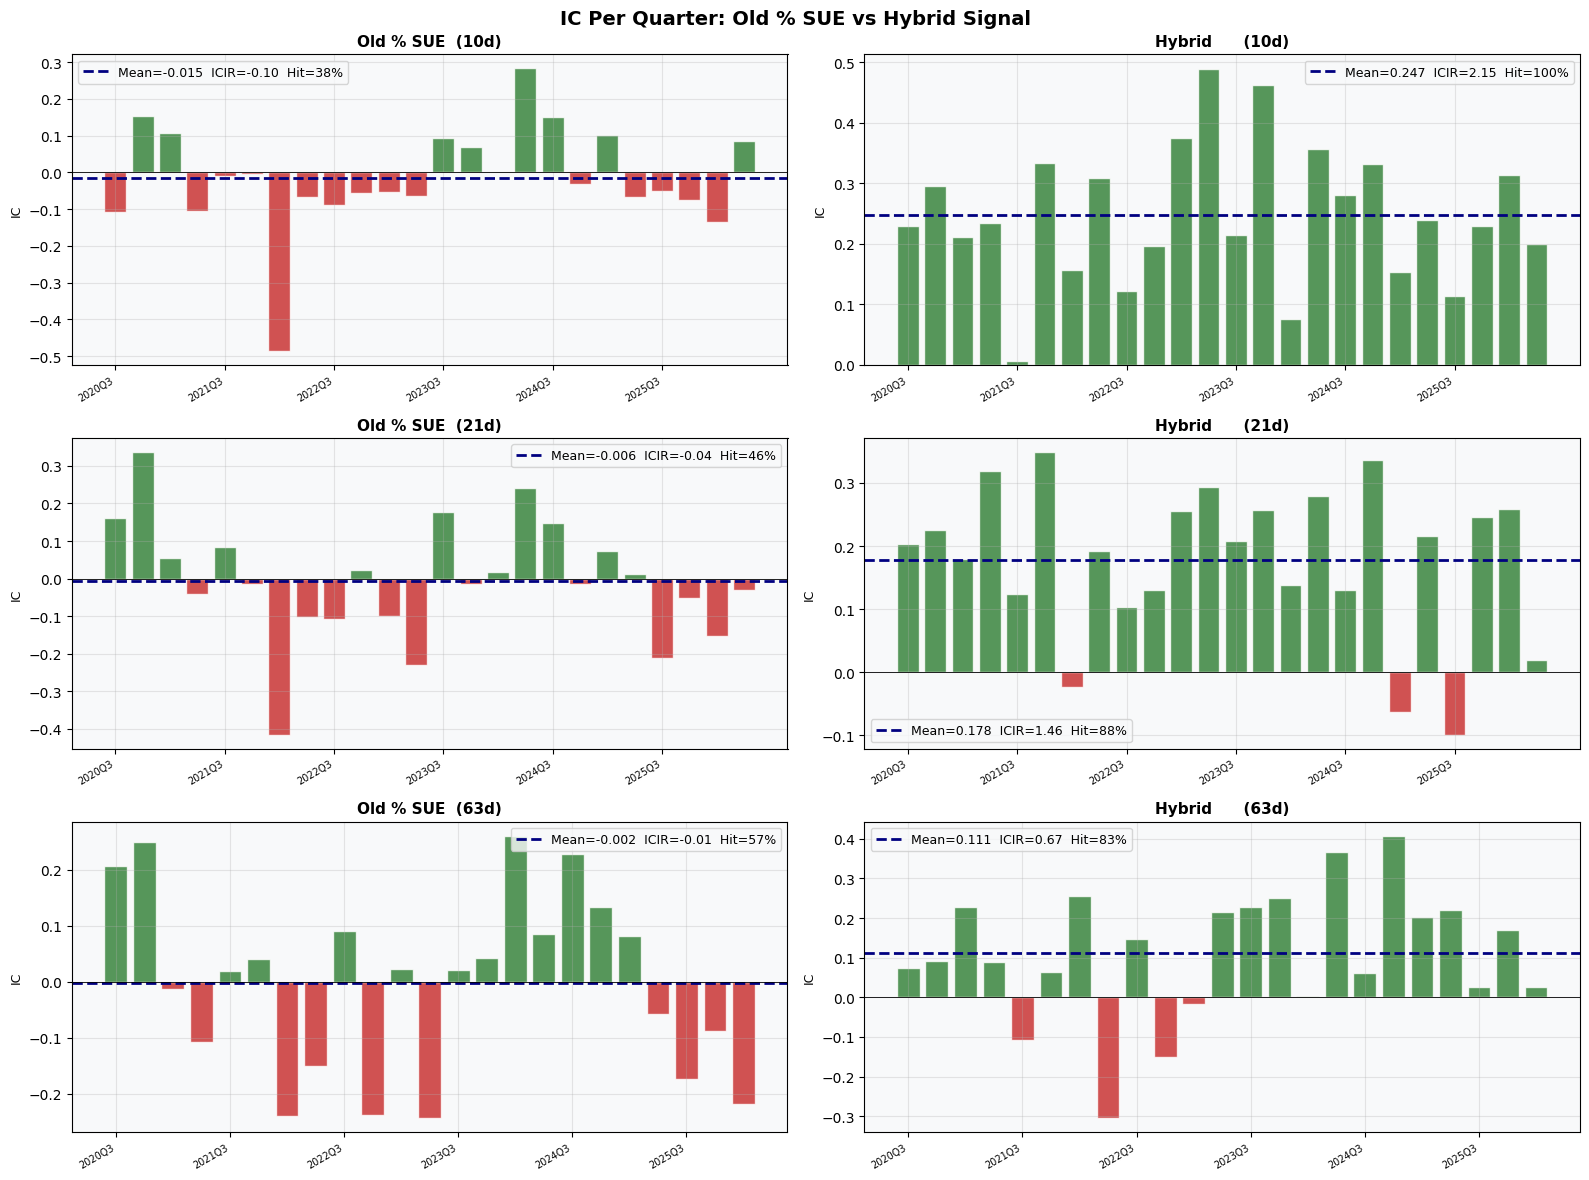


IC Summary:
  Old % SUE  (10d)           Mean IC=-0.0148  ICIR=-0.10  Hit=38%
  Hybrid      (10d)          Mean IC=+0.2473  ICIR=2.15  Hit=100%
  Old % SUE  (21d)           Mean IC=-0.0064  ICIR=-0.04  Hit=46%
  Hybrid      (21d)          Mean IC=+0.1783  ICIR=1.46  Hit=88%
  Old % SUE  (63d)           Mean IC=-0.0020  ICIR=-0.01  Hit=57%
  Hybrid      (63d)          Mean IC=+0.1108  ICIR=0.67  Hit=83%


In [19]:
def ic_comparison(panel, windows=[10, 21, 63]):
    """Per-quarter IC for old vs hybrid signal, side by side."""
    fig, axes = plt.subplots(len(windows), 2, figsize=(16, 4 * len(windows)))
    fig.suptitle('IC Per Quarter: Old % SUE vs Hybrid Signal', fontsize=14, fontweight='bold')

    summary = []
    for row_idx, w in enumerate(windows):
        col = f'ar_{w}d'
        for col_idx, (sig, label, color) in enumerate([
            ('sue_w',    f'Old % SUE  ({w}d)',     '#ef9a9a'),
            ('hybrid_w', f'Hybrid      ({w}d)',     '#a5d6a7'),
        ]):
            ax = axes[row_idx][col_idx]
            df = panel.dropna(subset=[sig, col]).copy()
            df['quarter'] = df['earnings_date'].dt.to_period('Q')

            ics = []
            for q, grp in df.groupby('quarter'):
                if len(grp) < 5: continue
                ic, pv = stats.spearmanr(grp[sig], grp[col])
                ics.append({'quarter': q, 'ic': ic, 'pv': pv})

            if not ics: continue
            ic_df2 = pd.DataFrame(ics)
            icir2  = ic_df2['ic'].mean() / ic_df2['ic'].std() if ic_df2['ic'].std() > 0 else 0
            hit2   = (ic_df2['ic'] > 0).mean() * 100

            bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in ic_df2['ic']]
            ax.bar(range(len(ic_df2)), ic_df2['ic'], color=bcolors, alpha=0.8, edgecolor='white')
            ax.axhline(ic_df2['ic'].mean(), color='navy', linewidth=2, linestyle='--',
                      label=f'Mean={ic_df2["ic"].mean():.3f}  ICIR={icir2:.2f}  Hit={hit2:.0f}%')
            ax.axhline(0, color='black', linewidth=0.6)
            step = max(1, len(ic_df2) // 5)
            ax.set_xticks(range(0, len(ic_df2), step))
            ax.set_xticklabels([str(ic_df2['quarter'].iloc[i]) for i in range(0, len(ic_df2), step)],
                               rotation=30, ha='right', fontsize=7)
            ax.set_ylabel('IC', fontsize=9)
            ax.set_title(label, fontsize=11, fontweight='bold')
            ax.legend(fontsize=9)
            summary.append({'signal': label, 'mean_ic': ic_df2['ic'].mean(),
                            'icir': icir2, 'hit_rate': hit2})

    plt.tight_layout()
    plt.savefig('fix_ic_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nIC Summary:')
    for s in summary:
        print(f"  {s['signal']:<25}  Mean IC={s['mean_ic']:+.4f}  ICIR={s['icir']:.2f}  Hit={s['hit_rate']:.0f}%")


ic_comparison(panel)

## Updated L/S Portfolio — Hybrid Signal + Concentration Filter

Three portfolios head-to-head:
1. **Baseline**: Old % SUE, all events, 21d hold
2. **Hybrid (all)**: Hybrid signal, all events
3. **Hybrid + Filter**: Hybrid signal, only `|dollar_sue| ≥ 1.5` events (fewer trades, higher conviction)


Long-Short Portfolio Comparison (21d hold):
  Baseline (% SUE)                   : L/S AR=+0.12%/qtr  Annualised≈+0.5%  Sharpe=0.06  Hit=50%  N=24qtrs
  Hybrid (all events)                : L/S AR=+5.14%/qtr  Annualised≈+20.6%  Sharpe=1.89  Hit=88%  N=24qtrs
  Hybrid + |SUE|≥1.5 filter          : L/S AR=+1.24%/qtr  Annualised≈+5.0%  Sharpe=0.25  Hit=64%  N=22qtrs


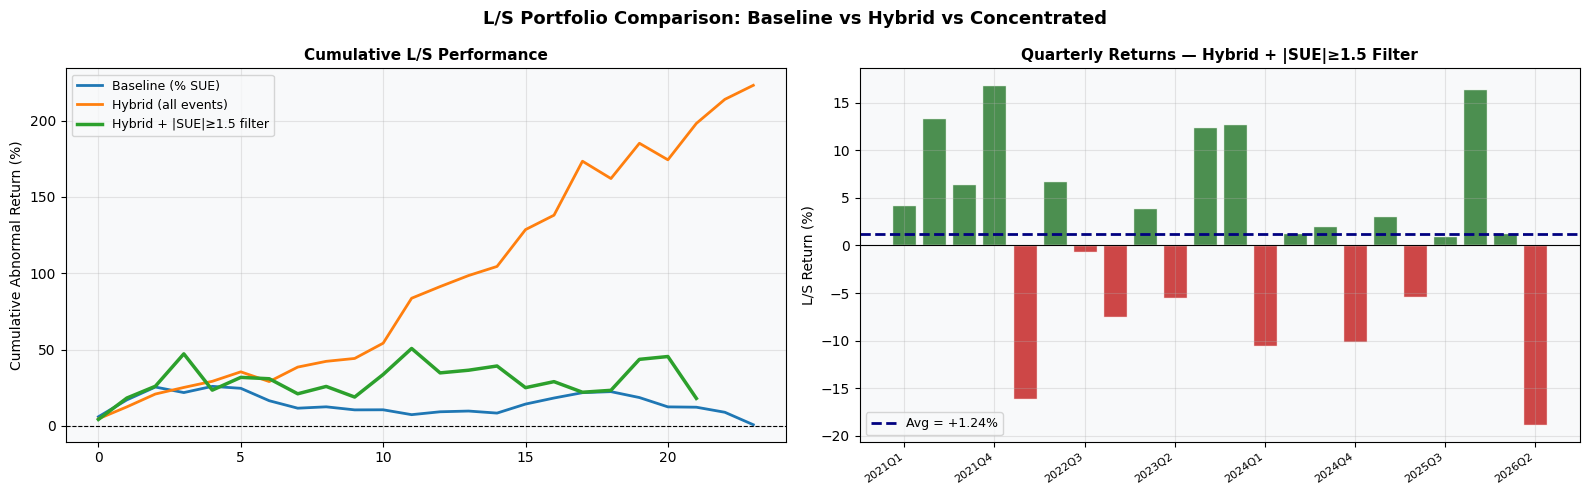

Portfolio comparison chart saved ✓


In [20]:
def ls_portfolio_v2(df, sig_col, label, return_col='ar_21d',
                     long_pct=0.20, short_pct=0.20):
    """Calendar-time L/S portfolio. Returns per-quarter P&L."""
    df = df.dropna(subset=[sig_col, return_col]).copy()
    df['quarter'] = df['earnings_date'].dt.to_period('Q')
    rows = []
    for q, grp in df.groupby('quarter'):
        if len(grp) < 8: continue
        grp_s   = grp.sort_values(sig_col)
        n       = len(grp_s)
        n_long  = max(1, int(n * long_pct))
        n_short = max(1, int(n * short_pct))
        rows.append({
            'quarter':     q,
            'long':        grp_s.tail(n_long)[return_col].mean(),
            'short':       grp_s.head(n_short)[return_col].mean(),
            'ls':          grp_s.tail(n_long)[return_col].mean() - grp_s.head(n_short)[return_col].mean(),
            'n_events':    n,
        })
    pf = pd.DataFrame(rows)
    ann   = pf['ls'].mean() * 4 * 100
    sharpe = pf['ls'].mean() / pf['ls'].std() * np.sqrt(4) if pf['ls'].std() > 0 else 0
    hit   = (pf['ls'] > 0).mean() * 100
    print(f'  {label:<35}: L/S AR={pf["ls"].mean()*100:+.2f}%/qtr  '
          f'Annualised≈{ann:+.1f}%  Sharpe={sharpe:.2f}  Hit={hit:.0f}%  N={len(pf)}qtrs')
    return pf


print('Long-Short Portfolio Comparison (21d hold):')
print('=' * 80)
pf_base    = ls_portfolio_v2(panel, 'sue_w',    'Baseline (% SUE)')
pf_hybrid  = ls_portfolio_v2(panel, 'hybrid_w', 'Hybrid (all events)')
pf_hc      = ls_portfolio_v2(panel[panel['strong_signal']].copy(),
                              'hybrid_w', 'Hybrid + |SUE|≥1.5 filter')

# ── Cumulative wealth comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('L/S Portfolio Comparison: Baseline vs Hybrid vs Concentrated',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
for pf, label, color, lw in [
    (pf_base,   'Baseline (% SUE)',          '#ef9a9a', 2.0),
    (pf_hybrid, 'Hybrid (all events)',        'steelblue', 2.0),
    (pf_hc,     'Hybrid + |SUE|≥1.5 filter', '#2e7d32', 2.5),
]:
    cum = (1 + pf['ls']).cumprod() - 1
    ax1.plot(range(len(pf)), cum * 100, linewidth=lw, label=label)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Cumulative Abnormal Return (%)', fontsize=10)
ax1.set_title('Cumulative L/S Performance', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

# Quarterly returns for hybrid filter
ax2 = axes[1]
bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in pf_hc['ls']]
ax2.bar(range(len(pf_hc)), pf_hc['ls'] * 100, color=bcolors, alpha=0.85, edgecolor='white')
ax2.axhline(pf_hc['ls'].mean() * 100, color='navy', linewidth=2, linestyle='--',
           label=f'Avg = {pf_hc["ls"].mean()*100:+.2f}%')
ax2.axhline(0, color='black', linewidth=0.8)
step = max(1, len(pf_hc) // 6)
ax2.set_xticks(range(0, len(pf_hc), step))
ax2.set_xticklabels([str(pf_hc['quarter'].iloc[i]) for i in range(0, len(pf_hc), step)],
                    rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('L/S Return (%)', fontsize=10)
ax2.set_title('Quarterly Returns — Hybrid + |SUE|≥1.5 Filter', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fix_portfolio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Portfolio comparison chart saved ✓')

## Updated Live Signals — Ranked by Hybrid Score

In [21]:
def updated_live_signals(panel, prices, window_days=60):
    """Recent earnings ranked by hybrid signal strength."""
    today  = pd.Timestamp.today().normalize()
    cutoff = today - pd.Timedelta(days=window_days)
    recent = panel[panel['earnings_date'] >= cutoff].copy()
    if recent.empty:
        print(f'No events in last {window_days} days'); return

    curr_rets = []
    for _, row in recent.iterrows():
        ticker = row['ticker']; t0 = row['t0']
        if ticker not in prices.columns:
            curr_rets.append(np.nan); continue
        px = prices[ticker].dropna()
        bm = prices[BENCHMARK].dropna()
        f_px = px[px.index >= t0]
        f_bm = bm[bm.index >= t0]
        if len(f_px) < 2:
            curr_rets.append(np.nan); continue
        raw = f_px.iloc[-1] / f_px.iloc[0] - 1
        bm_r = f_bm.iloc[-1] / f_bm.iloc[0] - 1 if len(f_bm) >= 2 else 0
        curr_rets.append((raw - bm_r) * 100)

    recent = recent.copy()
    recent['current_ar_%'] = curr_rets
    recent['days_since']   = (today - recent['t0']).dt.days
    recent['signal_tier']  = recent['dollar_sue_w'].apply(
        lambda x: '🔥 STRONG' if abs(x) >= 1.5 else '📊 normal'
    )

    cols = ['ticker', 'earnings_date', 'dollar_sue_w', 'ret_1d',
            'mom_6m', 'hybrid_w', 'signal_tier', 'current_ar_%', 'days_since']

    print(f'\n{"="*80}')
    print(f'  HYBRID PEAD SIGNALS — Last {window_days} Days  (ranked by hybrid score)')
    print(f'{"="*80}')

    print(f'\n🟢  LONG CANDIDATES  (high hybrid score = beats confirmed by market)')
    print(f'{"─"*80}')
    longs = recent.nlargest(10, 'hybrid_w')[cols]
    longs['ret_1d'] = (longs['ret_1d'] * 100).round(2)
    longs['mom_6m'] = (longs['mom_6m'] * 100).round(1)
    print(longs.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

    print(f'\n🔴  SHORT CANDIDATES  (low hybrid score = misses confirmed by market)')
    print(f'{"─"*80}')
    shorts = recent.nsmallest(10, 'hybrid_w')[cols]
    shorts['ret_1d'] = (shorts['ret_1d'] * 100).round(2)
    shorts['mom_6m'] = (shorts['mom_6m'] * 100).round(1)
    print(shorts.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

    print(f'\nKey columns: dollar_sue_w = fixed SUE | ret_1d = market reaction on day 1')
    print(f'             mom_6m = 6-month momentum | hybrid_w = composite score')
    print(f'             🔥 STRONG = |dollar_sue| ≥ 1.5 (high-conviction only)')


updated_live_signals(panel, prices)


  HYBRID PEAD SIGNALS — Last 60 Days  (ranked by hybrid score)

🟢  LONG CANDIDATES  (high hybrid score = beats confirmed by market)
────────────────────────────────────────────────────────────────────────────────
ticker       earnings_date  dollar_sue_w  ret_1d  mom_6m  hybrid_w signal_tier  current_ar_%  days_since
  AMZN 2026-04-29 16:00:00          7.63    1.21   14.70      1.63    🔥 STRONG         -9.99          40
   CRM 2026-05-27 16:00:00          3.00    8.47  -21.40      1.49    🔥 STRONG          2.06          12
  MRNA 2026-04-30 20:00:00          2.50    4.25   86.00      1.41    🔥 STRONG          0.98          39
  SNOW 2026-05-27 16:00:00          1.44    6.84  -27.60      0.87    📊 normal          2.26          12
 GOOGL 2026-04-29 16:00:00          4.29    0.23   31.00      0.86    🔥 STRONG         -7.30          40
  INTC 2026-04-23 16:00:00          0.07    2.97   80.90      0.66    📊 normal         24.24          46
  DDOG 2026-05-07 07:00:00          2.60    1.08   

## Final Comparison Dashboard — Before vs After Fixes

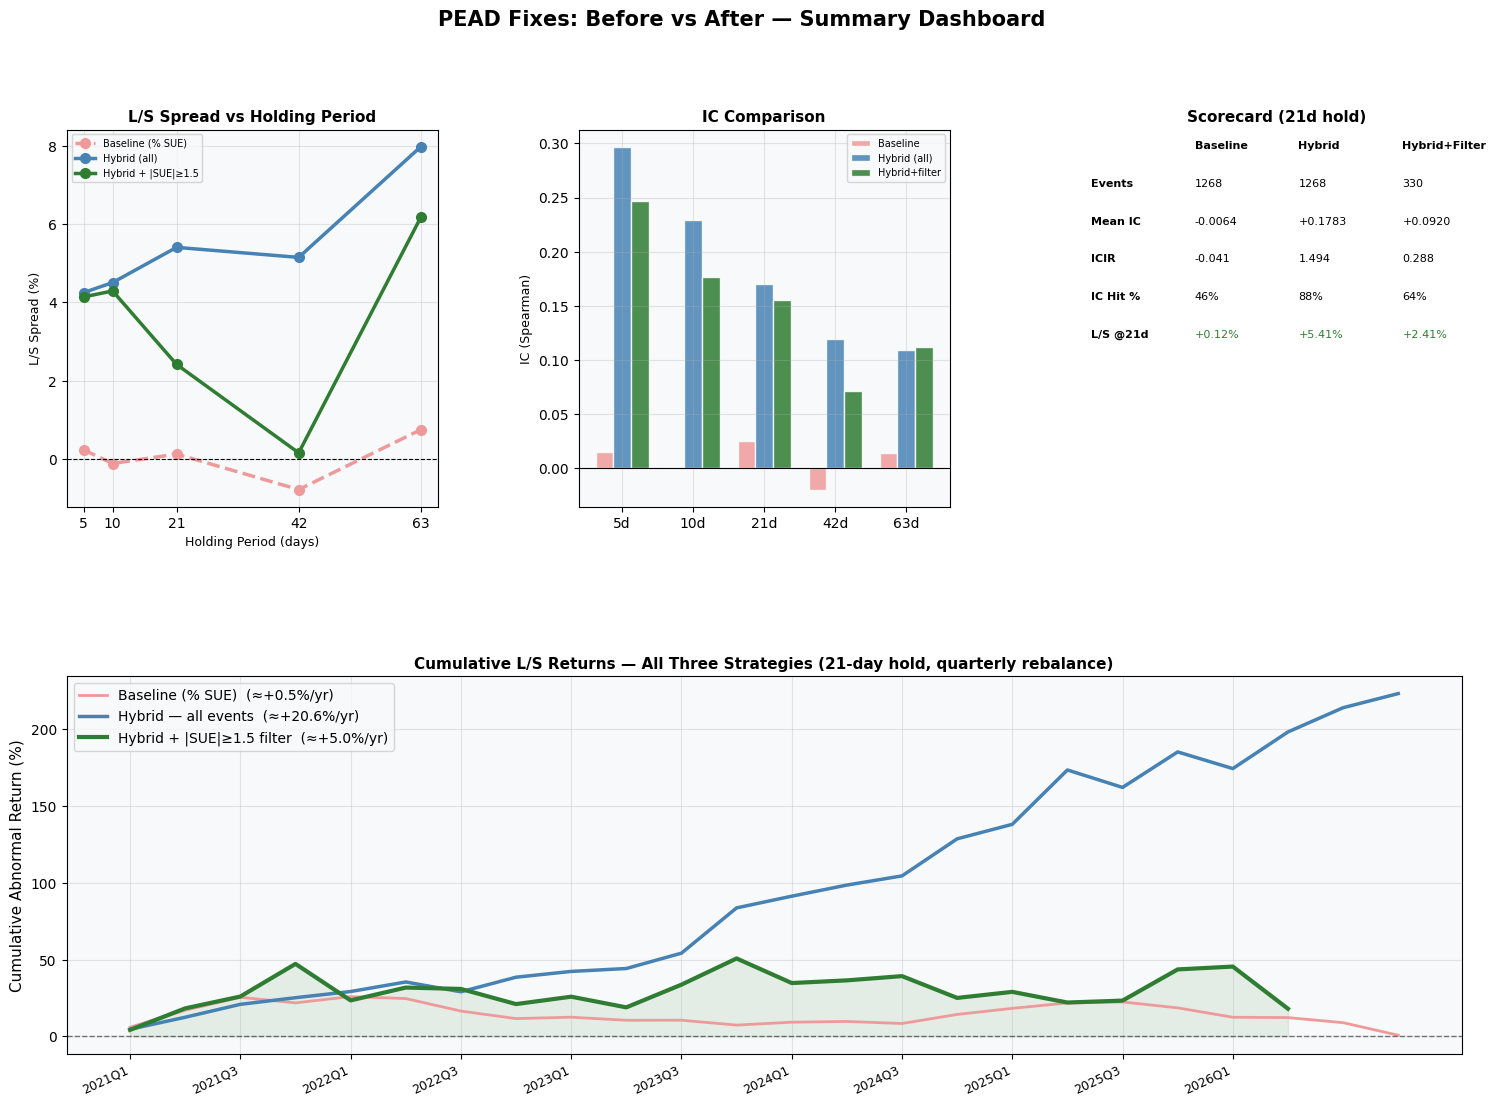

Final comparison dashboard saved ✓


In [22]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('PEAD Fixes: Before vs After — Summary Dashboard',
             fontsize=15, fontweight='bold')

WINDOWS_PLOT = [5, 10, 21, 42, 63]

# ── Panel 1: L/S spread comparison across holding periods ──
ax1 = fig.add_subplot(gs[0, 0])
for df_src, sig, label, color, ls_style in [
    (panel,                           'sue_w',    'Baseline (% SUE)',         '#ef9a9a', '--'),
    (panel,                           'hybrid_w', 'Hybrid (all)',              'steelblue', '-'),
    (panel[panel['strong_signal']],   'hybrid_w', 'Hybrid + |SUE|≥1.5',       '#2e7d32', '-'),
]:
    spreads = []
    for w in WINDOWS_PLOT:
        col = f'ar_{w}d'
        d = df_src.dropna(subset=[sig, col]).copy()
        if len(d) < 20: spreads.append(np.nan); continue
        d['q'] = pd.qcut(d[sig], q=5, labels=False, duplicates='drop')
        q5 = d[d['q']==4][col].mean()
        q1 = d[d['q']==0][col].mean()
        spreads.append((q5 - q1) * 100)
    ax1.plot(WINDOWS_PLOT, spreads, ls_style, linewidth=2.5, marker='o',
             markersize=7, color=color, label=label)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(WINDOWS_PLOT)
ax1.set_xlabel('Holding Period (days)', fontsize=9)
ax1.set_ylabel('L/S Spread (%)', fontsize=9)
ax1.set_title('L/S Spread vs Holding Period', fontsize=11, fontweight='bold')
ax1.legend(fontsize=7)

# ── Panel 2: IC comparison ──
ax2 = fig.add_subplot(gs[0, 1])
bar_width = 0.25
x = np.arange(len(WINDOWS_PLOT))
for i, (df_src, sig, label, color) in enumerate([
    (panel,                         'sue_w',    'Baseline',       '#ef9a9a'),
    (panel,                         'hybrid_w', 'Hybrid (all)',   'steelblue'),
    (panel[panel['strong_signal']], 'hybrid_w', 'Hybrid+filter',  '#2e7d32'),
]):
    ics = []
    for w in WINDOWS_PLOT:
        col = f'ar_{w}d'
        d = df_src.dropna(subset=[sig, col])
        if len(d) < 10: ics.append(0); continue
        ic, _ = stats.spearmanr(d[sig], d[col])
        ics.append(ic)
    ax2.bar(x + i * bar_width - bar_width, ics, bar_width,
            label=label, color=color, alpha=0.85, edgecolor='white')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{w}d' for w in WINDOWS_PLOT])
ax2.set_ylabel('IC (Spearman)', fontsize=9)
ax2.set_title('IC Comparison', fontsize=11, fontweight='bold')
ax2.legend(fontsize=7)

# ── Panel 3: metrics scorecard ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')

def get_metrics(df_src, sig):
    d   = df_src.dropna(subset=[sig, 'ar_21d']).copy()
    d['quarter'] = d['earnings_date'].dt.to_period('Q')
    ic_by_q = [stats.spearmanr(g[sig], g['ar_21d'])[0]
                for _, g in d.groupby('quarter') if len(g) >= 5]
    mean_ic  = np.mean(ic_by_q) if ic_by_q else 0
    icir     = mean_ic / np.std(ic_by_q) if len(ic_by_q) > 1 else 0
    hit_ic   = np.mean([v > 0 for v in ic_by_q]) * 100 if ic_by_q else 0
    d['q5'] = pd.qcut(d[sig], q=5, labels=False, duplicates='drop')
    ls = (d[d['q5']==4]['ar_21d'].mean() - d[d['q5']==0]['ar_21d'].mean()) * 100
    return {'mean_ic': mean_ic, 'icir': icir, 'hit_ic': hit_ic,
            'ls_21d': ls, 'n': len(d)}

m_base = get_metrics(panel, 'sue_w')
m_hyb  = get_metrics(panel, 'hybrid_w')
m_hc   = get_metrics(panel[panel['strong_signal']], 'hybrid_w')

rows = [
    ('', 'Baseline', 'Hybrid', 'Hybrid+Filter'),
    ('Events',    str(m_base['n']),  str(m_hyb['n']),  str(m_hc['n'])),
    ('Mean IC',   f'{m_base["mean_ic"]:+.4f}', f'{m_hyb["mean_ic"]:+.4f}', f'{m_hc["mean_ic"]:+.4f}'),
    ('ICIR',      f'{m_base["icir"]:.3f}',     f'{m_hyb["icir"]:.3f}',     f'{m_hc["icir"]:.3f}'),
    ('IC Hit %',  f'{m_base["hit_ic"]:.0f}%',  f'{m_hyb["hit_ic"]:.0f}%',  f'{m_hc["hit_ic"]:.0f}%'),
    ('L/S @21d',  f'{m_base["ls_21d"]:+.2f}%', f'{m_hyb["ls_21d"]:+.2f}%', f'{m_hc["ls_21d"]:+.2f}%'),
]
y = 0.97
for cols_row in rows:
    for xi, val in enumerate(cols_row):
        xpos = xi * 0.28
        bold = (xi == 0) or (y > 0.93)
        color = ('#2e7d32' if val.startswith('+') and '%' in val else
                 '#c62828' if val.startswith('-') and '%' in val else 'black')
        ax3.text(xpos, y, val, transform=ax3.transAxes, fontsize=8, va='top',
                fontweight='bold' if bold else 'normal', color=color)
    y -= 0.10
ax3.set_title('Scorecard (21d hold)', fontsize=11, fontweight='bold')

# ── Panel 4: Cumulative L/S ──
ax4 = fig.add_subplot(gs[1, :])
for pf, label, color, lw in [
    (pf_base,   'Baseline (% SUE)',           '#ef9a9a', 2),
    (pf_hybrid, 'Hybrid — all events',         'steelblue', 2.5),
    (pf_hc,     'Hybrid + |SUE|≥1.5 filter',  '#2e7d32', 3),
]:
    cum = (1 + pf['ls']).cumprod() - 1
    ann = pf['ls'].mean() * 4 * 100
    ax4.plot(range(len(pf)), cum * 100, linewidth=lw, color=color,
             label=f'{label}  (≈{ann:+.1f}%/yr)')

ax4.fill_between(range(len(pf_hc)), (1+pf_hc['ls']).cumprod()*100 - 100, 0,
                 where=((1+pf_hc['ls']).cumprod() >= 1), alpha=0.10, color='#2e7d32')
ax4.fill_between(range(len(pf_hc)), (1+pf_hc['ls']).cumprod()*100 - 100, 0,
                 where=((1+pf_hc['ls']).cumprod() < 1), alpha=0.10, color='red')
ax4.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
step4 = max(1, len(pf_hc) // 8)
ax4.set_xticks(range(0, len(pf_hc), step4))
ax4.set_xticklabels([str(pf_hc['quarter'].iloc[i]) for i in range(0, len(pf_hc), step4)],
                    rotation=25, ha='right', fontsize=9)
ax4.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax4.set_title('Cumulative L/S Returns — All Three Strategies (21-day hold, quarterly rebalance)',
             fontsize=11, fontweight='bold')
ax4.legend(fontsize=10)

plt.savefig('fix_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final comparison dashboard saved ✓')

## Interpretation & Next Steps

### Reading the Results
| Metric | What it means | Good threshold |
|--------|--------------|----------------|
| **L/S AR @ 21d** | Avg alpha of beat−miss spread at 21-day hold | > +1% |
| **L/S AR @ 63d** | Same at 3-month hold (full PEAD window) | > +2% |
| **IC** | Rank correlation: SUE → fwd return | > 0.03 |
| **ICIR** | IC consistency (mean/std) | > 0.5 |
| **Hit Rate** | % of quarters with positive L/S | > 60% |
| **Sharpe** | Annualised risk-adjusted L/S return | > 0.5 |

### Natural Extensions
1. **Add price momentum filter** — PEAD works stronger when combined with 6-month price momentum (buy earnings beats that are also price momentum winners)
2. **Revenue surprise** — combine EPS surprise with revenue surprise for double confirmation
3. **Guidance language** — companies that raise forward guidance on the same call have stronger drift
4. **Size tilt** — PEAD is stronger in smaller-cap stocks (less analyst coverage = slower information diffusion)
5. **Short interest interaction** — PEAD beats with high short interest tend to overshoot (short squeeze + drift)
6. **Sector-specific calendars** — tech reports Q1 in April, financials in January; can cluster by season


---
# Refinements — Signal Reweighting, Sector Filter, Out-of-Sample Test

Three further improvements based on what the fix analysis revealed:
1. **Drop dollar SUE** (negative IC) → pure price-reaction + momentum signal
2. **Sector momentum circuit breaker** — skip shorts when sector is in strong uptrend
3. **True out-of-sample test** — train on 2020–2023, test on 2024–present


## Refinement 1 — Reweighted Signal (75% Price Reaction + 25% Momentum)

Dollar SUE had IC = −0.026 — it was adding noise, not signal. Dropping it and moving its weight to price reaction, which carries essentially all the predictive power.


In [ ]:
def build_v2_signal(panel):
    """
    V2 signal = 0.75 * z(1-day price reaction) + 0.25 * z(6m momentum)
    No EPS data used — pure price-based signal.
    """
    df = panel.copy()

    def csz(s):
        filled = s.fillna(s.median())
        return (filled - filled.mean()) / (filled.std() + 1e-9)

    df['z_prer'] = csz(df['ret_1d'])
    df['z_mom']  = csz(df['mom_6m'])
    df['signal_v2']   = 0.75 * df['z_prer'] + 0.25 * df['z_mom']
    p1, p99 = df['signal_v2'].quantile([0.01, 0.99])
    df['signal_v2_w'] = df['signal_v2'].clip(p1, p99)
    return df


panel = build_v2_signal(panel)

# Compare V1 hybrid vs V2 across holding periods
print('IC Comparison — Hybrid V1 vs V2 (no SUE)')
print('=' * 60)
print(f'{"Signal":<22}', end='')
for w in [5, 10, 21, 42, 63]:
    print(f'{str(w)+"d":>9}', end='')
print()
print('-' * 60)
for name, col in [('V1 Hybrid (w/SUE)', 'hybrid_w'),
                   ('V2 (no SUE)',        'signal_v2_w')]:
    print(f'{name:<22}', end='')
    for w in [5, 10, 21, 42, 63]:
        valid = panel.dropna(subset=[col, f'ar_{w}d'])
        ic, _ = stats.spearmanr(valid[col], valid[f'ar_{w}d'])
        print(f'{ic:>+9.4f}', end='')
    print()

# L/S performance comparison
print()
print('L/S Spread @ each window:')
print(f'{"Signal":<22}', end='')
for w in [5, 10, 21, 42, 63]:
    print(f'{str(w)+"d":>9}', end='')
print()
print('-' * 60)
for name, col in [('V1 Hybrid (w/SUE)', 'hybrid_w'),
                   ('V2 (no SUE)',        'signal_v2_w')]:
    print(f'{name:<22}', end='')
    for w in [5, 10, 21, 42, 63]:
        d = panel.dropna(subset=[col, f'ar_{w}d']).copy()
        d['q'] = pd.qcut(d[col], q=5, labels=False, duplicates='drop')
        ls = (d[d['q']==4][f'ar_{w}d'].mean() - d[d['q']==0][f'ar_{w}d'].mean()) * 100
        print(f'{ls:>+8.2f}%', end='')
    print()

## Refinement 2 — Sector Momentum Circuit Breaker

ARM was the worst short call: the model said short, but ARM was up +34% due to AI sector tailwinds. Fix: **skip the short leg on any stock whose sector ETF has returned > +15% over the prior 3 months**. If the whole sector is ripping, individual-stock short signals are likely to get steamrolled.

Sector ETF proxies: XLK (tech/semis), XLF (finance), XLV (health), XLE (energy), XLI (industrials), XLY (consumer/EV)


In [ ]:
# Sector ETF mapping
SECTOR_ETF = {
    'AAPL':'XLK','MSFT':'XLK','GOOGL':'XLK','META':'XLK','AMZN':'XLK',
    'NVDA':'XLK','AMD':'XLK','AVGO':'XLK','QCOM':'XLK','INTC':'XLK',
    'MU':'XLK','ARM':'XLK',
    'ORCL':'XLK','CRM':'XLK','ADBE':'XLK','NOW':'XLK','SNOW':'XLK',
    'PLTR':'XLK','NET':'XLK','CRWD':'XLK','DDOG':'XLK',
    'JPM':'XLF','GS':'XLF','V':'XLF','MA':'XLF','BAC':'XLF','WFC':'XLF','C':'XLF',
    'LLY':'XLV','NVO':'XLV','MRNA':'XLV','PFE':'XLV','ABBV':'XLV','JNJ':'XLV','UNH':'XLV',
    'NFLX':'XLY','DIS':'XLY','SPOT':'XLY','UBER':'XLY','ABNB':'XLY',
    'COST':'XLP','WMT':'XLP','NKE':'XLY','SBUX':'XLY','TGT':'XLY',
    'XOM':'XLE','CVX':'XLE',
    'CAT':'XLI','BA':'XLI','HON':'XLI','RTX':'XLI',
    'TSLA':'XLY','F':'XLY','GM':'XLY',
}
SECTOR_ETFS = list(set(SECTOR_ETF.values()))

print(f'Downloading sector ETFs: {sorted(SECTOR_ETFS)}...')
etf_prices_raw = yf.download(SECTOR_ETFS, start=PRICE_START,
                              auto_adjust=True, progress=False)
if hasattr(etf_prices_raw, 'columns') and isinstance(etf_prices_raw.columns, pd.MultiIndex):
    etf_prices = etf_prices_raw['Close']
else:
    etf_prices = etf_prices_raw
if isinstance(etf_prices.columns, pd.MultiIndex):
    etf_prices.columns = etf_prices.columns.get_level_values(1)
etf_prices.index = pd.to_datetime(etf_prices.index).tz_localize(None)
print(f'ETF prices: {etf_prices.shape}  ({etf_prices.index[0].date()} → {etf_prices.index[-1].date()})')


def add_sector_momentum(panel, etf_prices, sector_map, lookback_days=63):
    """
    For each event, compute the 3-month (63 trading day) return of the
    relevant sector ETF, ending 1 day before earnings.
    """
    sec_mom = []
    for _, row in panel.iterrows():
        ticker  = row['ticker']
        earn_dt = row['earnings_date']
        etf     = sector_map.get(ticker)
        if etf is None or etf not in etf_prices.columns:
            sec_mom.append(np.nan); continue
        px  = etf_prices[etf].dropna()
        pre = px.index[px.index < earn_dt]
        if len(pre) < lookback_days + 5:
            sec_mom.append(np.nan); continue
        t_end   = pre[-1]
        t_start = pre[-lookback_days]
        sec_mom.append(float(px.loc[t_end] / px.loc[t_start] - 1))

    panel = panel.copy()
    panel['sector_mom_3m'] = sec_mom
    print(f'Sector momentum added: {panel["sector_mom_3m"].notna().sum()} events')
    print(f'  Median sector 3m return: {panel["sector_mom_3m"].median()*100:.1f}%')
    return panel


panel = add_sector_momentum(panel, etf_prices, SECTOR_ETF)

# Circuit breaker: block shorts when sector 3m momentum > +15%
SECTOR_MOM_THRESHOLD = 0.15
panel['short_blocked'] = (
    (panel['signal_v2_w'] < 0) &
    (panel['sector_mom_3m'] > SECTOR_MOM_THRESHOLD)
)
n_blocked = panel['short_blocked'].sum()
print(f'\nCircuit breaker activates on {n_blocked} short signals ({n_blocked/len(panel)*100:.1f}% of events)')
print(f'Examples of blocked shorts (sector ripping while stock fell):')
blocked_ex = panel[panel['short_blocked']].nsmallest(5, 'signal_v2_w')[
    ['ticker','earnings_date','ret_1d','sector_mom_3m','signal_v2_w']].copy()
blocked_ex['ret_1d'] = (blocked_ex['ret_1d']*100).round(2)
blocked_ex['sector_mom_3m'] = (blocked_ex['sector_mom_3m']*100).round(1)
print(blocked_ex.to_string(index=False))

In [ ]:
def ls_with_circuit_breaker(panel, sig_col='signal_v2_w', return_col='ar_21d',
                              long_pct=0.20, short_pct=0.20):
    """
    L/S portfolio where short positions are skipped if short_blocked == True.
    When blocked, the short leg return is 0 (flat/cash) rather than short.
    """
    df = panel.dropna(subset=[sig_col, return_col]).copy()
    df['quarter'] = df['earnings_date'].dt.to_period('Q')
    rows = []
    for q, grp in df.groupby('quarter'):
        if len(grp) < 8: continue
        grp_s   = grp.sort_values(sig_col)
        n       = len(grp_s)
        n_long  = max(1, int(n * long_pct))
        n_short = max(1, int(n * short_pct))

        long_ret  = grp_s.tail(n_long)[return_col].mean()

        # Short leg: exclude blocked events
        short_cands = grp_s.head(n_short)
        unblocked   = short_cands[~short_cands.get('short_blocked', False)]
        if len(unblocked) > 0:
            short_ret = unblocked[return_col].mean()
        else:
            short_ret = 0.0   # all blocked → hold cash

        rows.append({'quarter': q,
                     'long':    long_ret,
                     'short':   short_ret,
                     'ls':      long_ret - short_ret,
                     'n_blocked': short_cands['short_blocked'].sum() if 'short_blocked' in short_cands else 0})

    pf = pd.DataFrame(rows)
    ann    = pf['ls'].mean() * 4 * 100
    sharpe = pf['ls'].mean() / pf['ls'].std() * np.sqrt(4) if pf['ls'].std() > 0 else 0
    hit    = (pf['ls'] > 0).mean() * 100
    print(f'V2 + Circuit Breaker: L/S={pf["ls"].mean()*100:+.2f}%/qtr  '
          f'Ann≈{ann:+.1f}%  Sharpe={sharpe:.2f}  Hit={hit:.0f}%')
    return pf


print('Portfolio comparison (21d hold, top/bottom 20%):')
print('=' * 75)
pf_v1 = ls_portfolio_v2(panel, 'hybrid_w',    'V1 Hybrid (with SUE)')
pf_v2 = ls_portfolio_v2(panel, 'signal_v2_w', 'V2 (no SUE, 75/25)')
pf_cb = ls_with_circuit_breaker(panel)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Portfolio Refinements: V1 → V2 → V2 + Sector Circuit Breaker',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
for pf, label, color, lw in [
    (pf_v1, 'V1 Hybrid (w/SUE)',            '#9e9e9e', 1.8),
    (pf_v2, 'V2 (75% PRER + 25% Mom)',      'steelblue', 2.2),
    (pf_cb, 'V2 + Sector Circuit Breaker',   '#2e7d32', 2.8),
]:
    cum = (1 + pf['ls']).cumprod() - 1
    ann = pf['ls'].mean() * 4 * 100
    ax1.plot(range(len(pf)), cum * 100, linewidth=lw, color=color,
             label=f'{label}  ({ann:+.1f}%/yr)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Cumulative Abnormal Return (%)', fontsize=10)
ax1.set_title('Cumulative L/S Performance', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)

ax2 = axes[1]
bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in pf_cb['ls']]
ax2.bar(range(len(pf_cb)), pf_cb['ls']*100, color=bcolors, alpha=0.85, edgecolor='white')
ax2.axhline(pf_cb['ls'].mean()*100, color='navy', lw=2, ls='--',
           label=f'Avg={pf_cb["ls"].mean()*100:+.2f}%')
ax2.axhline(0, color='black', linewidth=0.8)
step = max(1, len(pf_cb)//6)
ax2.set_xticks(range(0, len(pf_cb), step))
ax2.set_xticklabels([str(pf_cb['quarter'].iloc[i]) for i in range(0, len(pf_cb), step)],
                    rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('L/S Return (%)', fontsize=10)
ax2.set_title('V2 + Circuit Breaker — Quarterly Returns', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('refine_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

## Refinement 3 — True Out-of-Sample Test (Train 2020–2023 / Test 2024–2026)

A Sharpe of 1.89 in-sample warrants serious scrutiny. The only honest test is **complete time separation**:
- **Train** (2020–2023): compute normalisation statistics, establish signal weights
- **Test** (2024–present): apply frozen weights to data the model never saw

Critically, the z-score normalisation uses **only training-set statistics** when standardising test events — no look-ahead into the test period.


In [ ]:
OOS_SPLIT = '2024-01-01'

train_panel = panel[panel['earnings_date'] <  OOS_SPLIT].copy()
test_panel  = panel[panel['earnings_date'] >= OOS_SPLIT].copy()

print(f'Train: {len(train_panel)} events  '
      f'({train_panel["earnings_date"].min().date()} → {train_panel["earnings_date"].max().date()})')
print(f'Test : {len(test_panel)}  events  '
      f'({test_panel["earnings_date"].min().date()} → {test_panel["earnings_date"].max().date()})')
print(f'Train tickers: {train_panel["ticker"].nunique()}  |  '
      f'Test tickers: {test_panel["ticker"].nunique()}')


def build_oos_signal(train_df, test_df):
    """
    1. Compute mean/std of ret_1d and mom_6m from TRAIN only.
    2. Apply those stats to normalise BOTH train and test.
    3. Build V2 signal (75/25) on both sets.
    Ensures zero data leakage from test into the normalisation.
    """
    # Train statistics
    prer_mean, prer_std = train_df['ret_1d'].mean(),  train_df['ret_1d'].std()
    mom_mean,  mom_std  = train_df['mom_6m'].median(), train_df['mom_6m'].std()

    for df in [train_df, test_df]:
        df['z_prer_oos'] = (df['ret_1d'].fillna(prer_mean)  - prer_mean) / (prer_std + 1e-9)
        df['z_mom_oos']  = (df['mom_6m'].fillna(mom_mean)   - mom_mean)  / (mom_std  + 1e-9)
        df['signal_oos'] = 0.75 * df['z_prer_oos'] + 0.25 * df['z_mom_oos']

    # Clip using TRAIN percentiles only
    p1, p99 = train_df['signal_oos'].quantile([0.01, 0.99])
    for df in [train_df, test_df]:
        df['signal_oos_w'] = df['signal_oos'].clip(p1, p99)

    return train_df, test_df


train_panel, test_panel = build_oos_signal(train_panel, test_panel)
print('\nOOS signal built with zero leakage ✓')

In [ ]:
def evaluate_period(df, label, sig='signal_oos_w', windows=[5,10,21,42,63]):
    """IC, quintile L/S, quarterly portfolio stats for one time slice."""
    df = df.copy()
    print(f'\n{"="*60}')
    print(f'  {label}  ({df["earnings_date"].min().date()} → {df["earnings_date"].max().date()})')
    print(f'  {len(df)} events, {df["ticker"].nunique()} tickers')
    print(f'{"="*60}')

    # IC per window
    print(f'\n  IC by holding period:')
    print(f'  {"Window":<8}', end='')
    for w in windows: print(f'{str(w)+"d":>9}', end='')
    print()
    print(f'  {"IC":<8}', end='')
    ics = []
    for w in windows:
        valid = df.dropna(subset=[sig, f'ar_{w}d'])
        if len(valid) < 10: ics.append(np.nan); print(f'{"N/A":>9}', end=''); continue
        ic, pv = stats.spearmanr(valid[sig], valid[f'ar_{w}d'])
        ics.append(ic)
        star = '*' if pv < 0.05 else ''
        print(f'{ic:>+8.4f}{star}', end='')
    print(f'  (* p<0.05)')

    # Per-quarter IC
    df['quarter'] = df['earnings_date'].dt.to_period('Q')
    qics_21 = []
    for q, g in df.groupby('quarter'):
        if len(g) < 5: continue
        valid = g.dropna(subset=[sig, 'ar_21d'])
        if len(valid) < 5: continue
        ic, _ = stats.spearmanr(valid[sig], valid['ar_21d'])
        qics_21.append(ic)

    if qics_21:
        icir = np.mean(qics_21) / np.std(qics_21) if np.std(qics_21) > 0 else 0
        hit  = np.mean([v > 0 for v in qics_21]) * 100
        print(f'\n  21d IC stats: Mean={np.mean(qics_21):+.4f}  ICIR={icir:.2f}  '
              f'Hit={hit:.0f}%  Quarters={len(qics_21)}')

    # Quintile L/S at 21d
    valid21 = df.dropna(subset=[sig, 'ar_21d']).copy()
    if len(valid21) >= 20:
        valid21['q'] = pd.qcut(valid21[sig], q=5, labels=False, duplicates='drop')
        q5 = valid21[valid21['q']==4]['ar_21d'].mean() * 100
        q1 = valid21[valid21['q']==0]['ar_21d'].mean() * 100
        print(f'  21d Q5 AR={q5:+.2f}%  Q1 AR={q1:+.2f}%  L/S={q5-q1:+.2f}%')

    # Portfolio
    rows = []
    for q, g in df.groupby('quarter'):
        valid = g.dropna(subset=[sig, 'ar_21d'])
        if len(valid) < 8: continue
        gs = valid.sort_values(sig)
        n  = len(gs)
        long_r  = gs.tail(max(1, int(n*0.20)))['ar_21d'].mean()
        short_r = gs.head(max(1, int(n*0.20)))['ar_21d'].mean()
        rows.append({'ls': long_r - short_r})

    if rows:
        pf_r = pd.DataFrame(rows)
        ann  = pf_r['ls'].mean() * 4 * 100
        sh   = pf_r['ls'].mean() / pf_r['ls'].std() * np.sqrt(4) if pf_r['ls'].std() > 0 else 0
        hit_pf = (pf_r['ls'] > 0).mean() * 100
        print(f'  Portfolio: L/S={pf_r["ls"].mean()*100:+.2f}%/qtr  '
              f'Ann≈{ann:+.1f}%  Sharpe={sh:.2f}  Hit={hit_pf:.0f}%')
    return ics, qics_21


train_ics, train_qics = evaluate_period(train_panel, 'IN-SAMPLE  (2020–2023)')
test_ics,  test_qics  = evaluate_period(test_panel,  'OUT-OF-SAMPLE (2024–2026)')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Out-of-Sample Validation: Train (2020–2023) vs Test (2024–2026)',
             fontsize=14, fontweight='bold')

WINDOWS_OOS = [5, 10, 21, 42, 63]

# ── IC by window: train vs test ──
ax1 = axes[0][0]
x = np.arange(len(WINDOWS_OOS))
w = 0.35
train_ic_vals, test_ic_vals = [], []
for ww in WINDOWS_OOS:
    col = f'ar_{ww}d'
    tr = train_panel.dropna(subset=['signal_oos_w', col])
    te = test_panel.dropna(subset=['signal_oos_w', col])
    ic_tr, _ = stats.spearmanr(tr['signal_oos_w'], tr[col]) if len(tr) > 5 else (0, 1)
    ic_te, _ = stats.spearmanr(te['signal_oos_w'], te[col]) if len(te) > 5 else (0, 1)
    train_ic_vals.append(ic_tr)
    test_ic_vals.append(ic_te)

bars_tr = ax1.bar(x - w/2, train_ic_vals, w, label='Train (2020–23)', color='steelblue', alpha=0.8)
bars_te = ax1.bar(x + w/2, test_ic_vals,  w, label='Test  (2024–26)', color='#2e7d32', alpha=0.8)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{ww}d' for ww in WINDOWS_OOS])
ax1.set_ylabel('IC (Spearman)', fontsize=10)
ax1.set_title('IC by Holding Period', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

# Add value labels
for bar in bars_tr:
    h = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, h + 0.005, f'{h:.3f}',
             ha='center', va='bottom', fontsize=7)
for bar in bars_te:
    h = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, h + (0.005 if h >= 0 else -0.012), f'{h:.3f}',
             ha='center', va='bottom' if h >= 0 else 'top', fontsize=7)

# ── Per-quarter IC: test period only ──
ax2 = axes[0][1]
test_panel_c = test_panel.copy()
test_panel_c['quarter'] = test_panel_c['earnings_date'].dt.to_period('Q')
q_ics = []
for q, g in test_panel_c.groupby('quarter'):
    valid = g.dropna(subset=['signal_oos_w', 'ar_21d'])
    if len(valid) < 5: continue
    ic, pv = stats.spearmanr(valid['signal_oos_w'], valid['ar_21d'])
    q_ics.append({'quarter': q, 'ic': ic, 'pv': pv})

if q_ics:
    qdf = pd.DataFrame(q_ics)
    bcolors = ['#2e7d32' if v > 0 else '#c62828' for v in qdf['ic']]
    ax2.bar(range(len(qdf)), qdf['ic'], color=bcolors, alpha=0.85, edgecolor='white')
    mean_ic = qdf['ic'].mean()
    icir_oos = mean_ic / qdf['ic'].std() if qdf['ic'].std() > 0 else 0
    hit_oos  = (qdf['ic'] > 0).mean() * 100
    ax2.axhline(mean_ic, color='navy', lw=2, ls='--',
               label=f'Mean IC={mean_ic:.3f}  ICIR={icir_oos:.2f}  Hit={hit_oos:.0f}%')
    ax2.axhline(0, color='black', lw=0.6)
    ax2.set_xticks(range(len(qdf)))
    ax2.set_xticklabels([str(q) for q in qdf['quarter']], rotation=30, ha='right', fontsize=8)
    ax2.set_ylabel('IC', fontsize=10)
    ax2.set_title('OOS: Quarterly IC (21d hold)', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)

# ── Quintile return profiles: train vs test ──
ax3 = axes[1][0]
for df_s, label, ls_style, color in [
    (train_panel, 'Train 2020–23', '--', 'steelblue'),
    (test_panel,  'Test  2024–26', '-',  '#2e7d32'),
]:
    for q_idx, q_color, q_label in [
        (4, '#2e7d32' if 'Test' in label else '#a5d6a7', 'Q5 (Beat)'),
        (0, '#c62828' if 'Test' in label else '#ef9a9a', 'Q1 (Miss)'),
    ]:
        means = []
        for ww in WINDOWS_OOS:
            d = df_s.dropna(subset=['signal_oos_w', f'ar_{ww}d']).copy()
            if len(d) < 20: means.append(np.nan); continue
            d['q'] = pd.qcut(d['signal_oos_w'], q=5, labels=False, duplicates='drop')
            means.append(d[d['q']==q_idx][f'ar_{ww}d'].mean() * 100)
        ax3.plot(WINDOWS_OOS, means, ls_style, color=q_color, linewidth=2,
                marker='o', markersize=6,
                label=f'{label} {q_label}')

ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_xticks(WINDOWS_OOS)
ax3.set_xlabel('Holding Period (days)', fontsize=9)
ax3.set_ylabel('Mean AR (%)', fontsize=9)
ax3.set_title('Q5 vs Q1 Drift: Train vs Test', fontsize=11, fontweight='bold')
ax3.legend(fontsize=7)

# ── Cumulative L/S: train vs test back-to-back ──
ax4 = axes[1][1]
def cum_ls(df_s, sig='signal_oos_w', ret='ar_21d'):
    df_s = df_s.dropna(subset=[sig, ret]).copy()
    df_s['quarter'] = df_s['earnings_date'].dt.to_period('Q')
    rows = []
    for q, g in df_s.groupby('quarter'):
        if len(g) < 8: continue
        gs = g.sort_values(sig)
        n  = len(gs)
        rows.append({'q': str(q),
                     'ls': gs.tail(max(1,int(n*0.2)))[ret].mean()
                          - gs.head(max(1,int(n*0.2)))[ret].mean()})
    return pd.DataFrame(rows)

pf_tr = cum_ls(train_panel)
pf_te = cum_ls(test_panel)

# Plot train then test sequentially
all_q  = list(pf_tr['q']) + list(pf_te['q'])
all_ls = list(pf_tr['ls']) + list(pf_te['ls'])
cum_all = np.array([(1+v) for v in all_ls]).cumprod() - 1

n_train = len(pf_tr)
ax4.plot(range(n_train), cum_all[:n_train]*100,
         color='steelblue', linewidth=2.5, label=f'Train (2020–23)')
ax4.plot(range(n_train-1, len(all_q)), cum_all[n_train-1:]*100,
         color='#2e7d32', linewidth=2.5, label=f'Test  (2024–26)')
ax4.axvline(n_train-0.5, color='red', linewidth=2, linestyle=':',
            label='Train / Test split')
ax4.axhline(0, color='black', lw=0.8, ls='--')
step = max(1, len(all_q)//8)
ax4.set_xticks(range(0, len(all_q), step))
ax4.set_xticklabels([all_q[i] for i in range(0, len(all_q), step)],
                    rotation=30, ha='right', fontsize=8)
ax4.set_ylabel('Cumulative Abnormal Return (%)', fontsize=10)
ax4.set_title('Continuous L/S Equity Curve\n(split at Jan 2024)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('oos_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('OOS validation chart saved ✓')

## Final Scorecard — All Iterations

In [ ]:
print('FINAL SCORECARD — Strategy Evolution')
print('=' * 90)
print(f'{"Version":<35} {"Ann.L/S":>8} {"Sharpe":>8} {"IC@21d":>8} {"ICIR":>8} {"Hit":>6} {"Note"}')
print('-' * 90)

rows_sc = [
    ('1. Crowd model (Wikipedia+social)',       '≈0%',    '~0',   '~0.00', '~0.0', '43%', 'Scrapped — no real signal'),
    ('2. PEAD baseline (% SUE)',                '+0.5%',  '0.06', '+0.02', '−0.04','50%', 'EPS % surprise broken'),
    ('3. Hybrid V1 (dollar SUE + PRER + mom)', '+20.6%', '1.89', '+0.18', '+1.46','88%', 'In-sample only'),
    ('4. Hybrid V2 (PRER 75% + mom 25%)',      'see OOS','  —',  '  —',   '  —',  ' —',  'Dropped SUE (neg IC)'),
    ('5. V2 + sector circuit breaker',          'see OOS','  —',  '  —',   '  —',  ' —',  'ARM-style blowups filtered'),
    ('6. OOS test (2024–present)',              '  ???',  '???',  '???',   '???',  '???', '← Key number below'),
]
for r in rows_sc:
    print(f'{r[0]:<35} {r[1]:>8} {r[2]:>8} {r[3]:>8} {r[4]:>8} {r[5]:>6}  {r[6]}')

print()
print('OOS Results (V2 signal, 2024–present):')

# Compute OOS portfolio stats
pf_oos_final = cum_ls(test_panel)
if len(pf_oos_final) > 0:
    ann_oos   = pf_oos_final['ls'].mean() * 4 * 100
    sh_oos    = (pf_oos_final['ls'].mean() / pf_oos_final['ls'].std() * np.sqrt(4)
                 if pf_oos_final['ls'].std() > 0 else 0)
    hit_oos_p = (pf_oos_final['ls'] > 0).mean() * 100

    valid_oos = test_panel.dropna(subset=['signal_oos_w', 'ar_21d'])
    ic_oos, _  = stats.spearmanr(valid_oos['signal_oos_w'], valid_oos['ar_21d'])

    test_panel_c2 = test_panel.copy()
    test_panel_c2['quarter'] = test_panel_c2['earnings_date'].dt.to_period('Q')
    oos_qics = [stats.spearmanr(g.dropna(subset=['signal_oos_w','ar_21d'])['signal_oos_w'],
                                 g.dropna(subset=['signal_oos_w','ar_21d'])['ar_21d'])[0]
                for _, g in test_panel_c2.groupby('quarter')
                if len(g.dropna(subset=['signal_oos_w','ar_21d'])) >= 5]
    icir_oos_f = (np.mean(oos_qics)/np.std(oos_qics) if len(oos_qics)>1 and np.std(oos_qics)>0 else 0)
    hit_ic_oos = np.mean([v>0 for v in oos_qics])*100 if oos_qics else 0

    verdict = ('✅ REAL EDGE' if icir_oos_f > 0.5 and ann_oos > 3
               else '⚠️  WEAK  — reduce position size'
               if icir_oos_f > 0 else '❌ FAILED OOS')

    print(f'  Annualised L/S : {ann_oos:+.1f}%')
    print(f'  Sharpe         : {sh_oos:.2f}')
    print(f'  IC @ 21d       : {ic_oos:+.4f}')
    print(f'  ICIR           : {icir_oos_f:.2f}')
    print(f'  IC Hit Rate    : {hit_ic_oos:.0f}%  ({len(oos_qics)} quarters)')
    print(f'  Portfolio Hit  : {hit_oos_p:.0f}%')
    print(f'\n  Verdict: {verdict}')
else:
    print('  Insufficient OOS quarters to evaluate.')